### Introduction

The code consists of training and test process on epochs 20 with combination of learning rates {1e-3, 1e-4, 1e-5} and batch size {32, 64}. The results of two-stage architecture are based on respective best three models under 20 epochs. The final two-stage architecture results please refer to the 'Evaluation' code. 

In [ ]:
# Copyright 2025 ETH Zurich
# Project contributors:
#   Fan Wu (ETH Zurich)
#   Kaicheng Zhao (RWTH Aachen University)
# SPDX-License-Identifier: Apache-2.0
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

###   EXP 1: one stage classifier

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet50_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

base_path = '/content/MA'
output_dir = base_path

# Class Mapping

classes = {
    "ALS": 0,
    "Covid-19": 1,
    "Dysphonie": 2,
    "HC": 3,
    "Laryngitis": 4,
    "Parkinson": 5,
    "Rekurrensparese": 6
}

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32)
        if mel.ndim == 2:
            mel = mel.unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

# Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes=7):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

train_set_path = os.path.join(base_path, "/content/MA/train_set.xlsx")
test_set_path = os.path.join(base_path, "/content/MA/test_set.xlsx")
train_df = pd.read_excel(train_set_path)
test_df = pd.read_excel(test_set_path)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        pathology = row['Pathology']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and pathology in classes:
            files.append(full_path)
            labels.append(classes[pathology])
        else:
            print(f"Warning: File {full_path} does not exist or invalid pathology.")
    return files, labels

train_files, train_labels = get_file_paths_and_labels(train_df, base_path)
test_files, test_labels = get_file_paths_and_labels(test_df, base_path)

test_dataset = MelDataset(test_files, test_labels)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Loss curve (optional)
def plot_loss(train_losses, val_losses, fold):
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Train vs Validation Loss - Fold {fold}")
    plt.legend()
    plt.savefig(os.path.join(output_dir, f"loss_curve_fold_{fold}.png"))
    plt.close()

# Validation MCC
def save_metrics(metrics, fold):
    metrics_df = pd.DataFrame(metrics, columns=["Epoch", "MCC"])
    metrics_df.to_csv(os.path.join(output_dir, f"validation_metrics_fold_{fold}.csv"), index=False)

# Test Set Evaluation
def evaluate_on_test_set(model, test_loader, fold):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

    # Confusion Matrix
    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Test Set (Fold {fold})")
    plt.savefig(os.path.join(output_dir, f"test_confusion_matrix_fold_{fold}.png"))
    plt.close()

    mcc = matthews_corrcoef(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"Test Set Results - Fold {fold}: MCC: {mcc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

    # Test Set index
    test_results_path = os.path.join(output_dir, "test_metrics.csv")
    if not os.path.exists(test_results_path):
        with open(test_results_path, "w") as f:
            f.write("Fold,MCC,Precision,Recall,F1\n")
    with open(test_results_path, "a") as f:
        f.write(f"{fold},{mcc:.4f},{precision:.4f},{recall:.4f},{f1:.4f}\n")

cv_results = []

best_params = None
best_model = None
best_val_mcc = -float('inf')

for batch_size, lr in itertools.product([32, 64], [1e-3, 1e-4, 1e-5]):
    print(f"Testing parameter combination: batch_size={batch_size}, lr={lr}")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
    fold = 1
    fold_metrics = []

    for train_idx, val_idx in skf.split(train_files, train_labels):
        print(f"Starting Fold {fold} with batch_size={batch_size}, lr={lr}")

        train_dataset = MelDataset([train_files[i] for i in train_idx], [train_labels[i] for i in train_idx])
        val_dataset = MelDataset([train_files[i] for i in val_idx], [train_labels[i] for i in val_idx])
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        model = ResNet50Classifier(num_classes=len(classes)).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        train_losses, val_losses = [], []

        for epoch in range(20):
            model.train()
            total_train_loss = 0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                total_train_loss += loss.item()

            model.eval()
            total_val_loss = 0
            y_true, y_pred = [], []
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    total_val_loss += loss.item()
                    y_true.extend(labels.cpu().numpy())
                    y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

            train_loss = total_train_loss / len(train_loader)
            val_loss = total_val_loss / len(val_loader)
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

        mcc = matthews_corrcoef(y_true, y_pred)
        fold_metrics.append(mcc)
        print(f"Fold {fold} | MCC: {mcc:.4f}")
        fold += 1

    avg_mcc = np.mean(fold_metrics)
    std_mcc = np.std(fold_metrics)
    print(f"Cross-Validation Results for batch_size={batch_size}, lr={lr}: Avg MCC={avg_mcc:.4f}, Std MCC={std_mcc:.4f}")
    cv_results.append((batch_size, lr, avg_mcc, std_mcc))

    if avg_mcc > best_val_mcc:
        best_val_mcc = avg_mcc
        best_params = (batch_size, lr)
        best_model = model

cv_results_df = pd.DataFrame(cv_results, columns=["Batch Size", "Learning Rate", "Avg MCC", "Std MCC"])
cv_results_df.to_csv(os.path.join(output_dir, "cv_results.csv"), index=False)
print(cv_results_df)


print(f"Best Parameters Found: Batch Size={best_params[0]}, Learning Rate={best_params[1]}, Avg MCC={best_val_mcc:.4f}")
# Retrain on whole training set
print("Retraining model with best parameters on full training set...")
final_train_dataset = MelDataset(train_files, train_labels)
final_train_loader = DataLoader(final_train_dataset, batch_size=best_params[0], shuffle=True)
final_model = ResNet50Classifier(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params[1])

for epoch in range(20):
    final_model.train()
    total_train_loss = 0
    for inputs, labels in final_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = final_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(final_train_loader)
    print(f"Retrain Epoch {epoch + 1}: Train Loss: {avg_train_loss:.4f}")

torch.save(final_model.state_dict(), os.path.join(output_dir, "final_model.pth"))
print("Final trained model saved successfully.")

print("Evaluating final model on test set...")
evaluate_on_test_set(final_model, test_loader, "Final")


Using device: cuda
Testing parameter combination: batch_size=32, lr=0.001
Starting Fold 1 with batch_size=32, lr=0.001


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 214MB/s]


Epoch 1: Train Loss: 0.7742, Validation Loss: 0.7963
Epoch 2: Train Loss: 0.6036, Validation Loss: 0.6702
Epoch 3: Train Loss: 0.5313, Validation Loss: 0.6394
Epoch 4: Train Loss: 0.5005, Validation Loss: 0.5617
Epoch 5: Train Loss: 0.4309, Validation Loss: 0.4719
Epoch 6: Train Loss: 0.3831, Validation Loss: 0.3927
Epoch 7: Train Loss: 0.3396, Validation Loss: 0.3745
Epoch 8: Train Loss: 0.3093, Validation Loss: 0.3420
Epoch 9: Train Loss: 0.2817, Validation Loss: 0.3528
Epoch 10: Train Loss: 0.2165, Validation Loss: 0.3191
Epoch 11: Train Loss: 0.2119, Validation Loss: 0.2790
Epoch 12: Train Loss: 0.1737, Validation Loss: 0.3749
Epoch 13: Train Loss: 0.1497, Validation Loss: 0.3303
Epoch 14: Train Loss: 0.1472, Validation Loss: 0.2891
Epoch 15: Train Loss: 0.1084, Validation Loss: 0.3245
Epoch 16: Train Loss: 0.2551, Validation Loss: 0.3179
Epoch 17: Train Loss: 0.0946, Validation Loss: 0.2389
Epoch 18: Train Loss: 0.0651, Validation Loss: 0.2759
Epoch 19: Train Loss: 0.0631, Validat

In [ ]:
### EXP 2: two stage architecture classifier

In [ ]:
### classifier PD training

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet50_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

base_path = '/content/MA'
output_dir = base_path

# Class Mapping
classes = {
    "MC": 0,  # Male Control
    "MP": 1,  # Male Pathology
    "FC": 2,  # Female Control
    "FP": 3   # Female Pathology
}

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32)
        if mel.ndim == 2:
            mel = mel.unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

#  Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes=4):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        group = row['Group']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and group in classes:
            files.append(full_path)
            labels.append(classes[group])
        else:
            print(f"Warning: File {full_path} does not exist or invalid group.")
    return files, labels

train_set_path = os.path.join(base_path, "train_set.xlsx")
test_set_path = os.path.join(base_path, "test_set.xlsx")
train_df = pd.read_excel(train_set_path)
test_df = pd.read_excel(test_set_path)

train_files, train_labels = get_file_paths_and_labels(train_df, base_path)
test_files, test_labels = get_file_paths_and_labels(test_df, base_path)

test_dataset = MelDataset(test_files, test_labels)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

def plot_loss(train_losses, val_losses, fold):
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Train vs Validation Loss - Fold {fold}")
    plt.legend()
    plt.savefig(os.path.join(output_dir, f"loss_curve_fold_{fold}.png"))
    plt.close()

def save_metrics(metrics, fold):
    metrics_df = pd.DataFrame(metrics, columns=["Epoch", "MCC"])
    metrics_df.to_csv(os.path.join(output_dir, f"validation_metrics_fold_{fold}.csv"), index=False)

def save_test_metrics(fold, mcc):
    test_results_path = os.path.join(output_dir, "test_metrics.csv")
    if not os.path.exists(test_results_path):
        with open(test_results_path, "w") as f:
            f.write("Fold,MCC\n")
    with open(test_results_path, "a") as f:
        f.write(f"{fold},{mcc:.4f}\n")

def evaluate_on_test_set(model, test_loader, fold):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Test Set (Fold {fold})")
    plt.savefig(os.path.join(output_dir, f"test_confusion_matrix_fold_{fold}.png"))
    plt.close()

    mcc = matthews_corrcoef(y_true, y_pred)
    print(f"Test Set Results - Fold {fold}: MCC: {mcc:.4f}")
    save_test_metrics(fold, mcc)

batch_sizes = [32, 64]
learning_rates = [1e-3, 1e-4, 1e-5]
param_combinations = list(itertools.product(batch_sizes, learning_rates))

best_params = None
best_model = None
best_val_mcc = -1

cv_results = []

for batch_size, lr in param_combinations:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
    fold = 1

    last_mcc_values = []

    for train_idx, val_idx in skf.split(train_files, train_labels):
        print(f"Starting Fold {fold} with batch_size={batch_size}, lr={lr}")

        train_dataset = MelDataset([train_files[i] for i in train_idx], [train_labels[i] for i in train_idx])
        val_dataset = MelDataset([train_files[i] for i in val_idx], [train_labels[i] for i in val_idx])
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        model = ResNet50Classifier(num_classes=len(classes)).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        train_losses, val_losses = [], []

        for epoch in range(20):
            model.train()
            total_train_loss = 0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                total_train_loss += loss.item()

            model.eval()
            total_val_loss = 0
            y_true, y_pred = [], []
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    total_val_loss += loss.item()
                    y_true.extend(labels.cpu().numpy())
                    y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

            train_loss = total_train_loss / len(train_loader)
            val_loss = total_val_loss / len(val_loader)
            train_losses.append(train_loss)
            val_losses.append(val_loss)

            print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

        last_mcc = matthews_corrcoef(y_true, y_pred)
        last_mcc_values.append(last_mcc)
        print(f"Fold {fold} | MCC: {last_mcc:.4f}")
        fold += 1

    avg_mcc = np.mean(last_mcc_values)
    print(f"Average MCC for batch_size={batch_size}, lr={lr}: {avg_mcc:.4f}")

    if avg_mcc > best_val_mcc:
        best_val_mcc = avg_mcc
        best_params = (batch_size, lr)
        best_model = model

print(f"Best Parameters: batch_size={best_params[0]}, lr={best_params[1]} with MCC={best_val_mcc:.4f}")

# Retrain on whole test set
final_train_dataset = MelDataset(train_files, train_labels)
final_train_loader = DataLoader(final_train_dataset, batch_size=best_params[0], shuffle=True)
final_model = ResNet50Classifier(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params[1])

train_losses = []

for epoch in range(20):
    final_model.train()
    total_train_loss = 0
    for inputs, labels in final_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = final_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(final_train_loader)
    train_losses.append(avg_train_loss)
    print(f"Retrain Epoch {epoch + 1}: Train Loss: {avg_train_loss:.4f}")

final_model_save_path = os.path.join(output_dir, "final_group_classifier.pth")
torch.save(final_model.state_dict(), final_model_save_path)
print(f"Final model saved to {final_model_save_path}")

final_model.load_state_dict(torch.load(final_model_save_path))
evaluate_on_test_set(final_model, test_loader, "Final")


Using device: cuda
Starting Fold 1 with batch_size=32, lr=0.001


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 181MB/s]


Epoch 1: Train Loss: 0.7511, Validation Loss: 0.7173
Epoch 2: Train Loss: 0.5827, Validation Loss: 0.5507
Epoch 3: Train Loss: 0.4999, Validation Loss: 0.5973
Epoch 4: Train Loss: 0.4055, Validation Loss: 0.5006
Epoch 5: Train Loss: 0.3521, Validation Loss: 0.5309
Epoch 6: Train Loss: 0.2964, Validation Loss: 0.4982
Epoch 7: Train Loss: 0.2417, Validation Loss: 0.4229
Epoch 8: Train Loss: 0.1937, Validation Loss: 0.3868
Epoch 9: Train Loss: 0.1715, Validation Loss: 0.3360
Epoch 10: Train Loss: 0.1849, Validation Loss: 0.2820
Epoch 11: Train Loss: 0.1115, Validation Loss: 0.4271
Epoch 12: Train Loss: 0.1349, Validation Loss: 0.3012
Epoch 13: Train Loss: 0.1100, Validation Loss: 0.3059
Epoch 14: Train Loss: 0.0762, Validation Loss: 0.3334
Epoch 15: Train Loss: 0.0992, Validation Loss: 0.4708
Epoch 16: Train Loss: 0.1024, Validation Loss: 0.2809
Epoch 17: Train Loss: 0.0680, Validation Loss: 0.2786
Epoch 18: Train Loss: 0.0366, Validation Loss: 0.4181
Epoch 19: Train Loss: 0.0638, Validat

<ipython-input-2-724506df6f05>:257: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_model.load_state_dict(torch.load(final_model_save_path))


Test Set Results - Fold Final: MCC: 0.9458


In [ ]:
## classifier PD test

<ipython-input-3-99cc715392d4>:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_model.load_state_dict(torch.load('/content/MA/final_group_classifier.pth'))


Precision: 0.9628
Recall: 0.9626
F1 Score: 0.9627
MCC: 0.9458


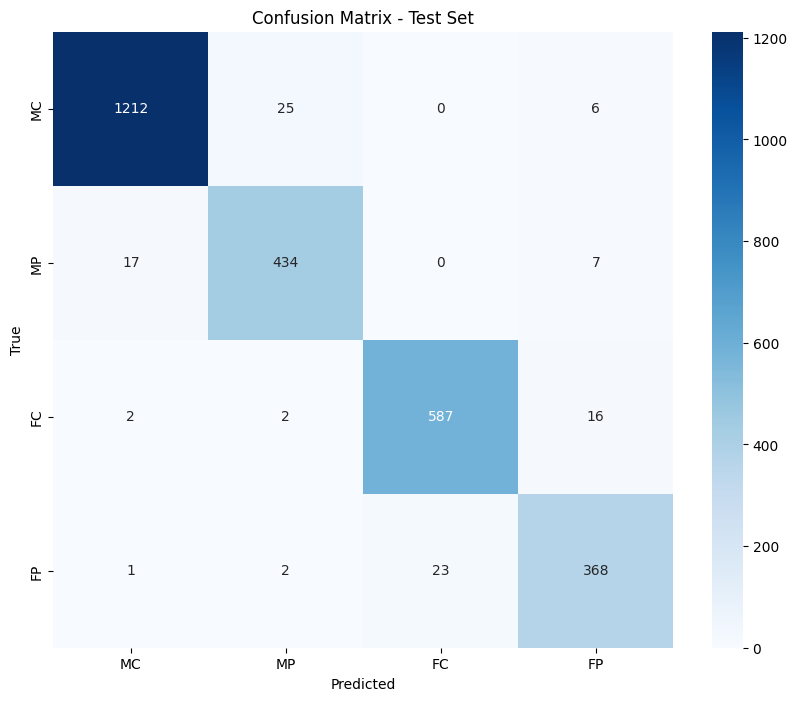

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model_on_test_set(model, test_loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            predictions = torch.argmax(outputs, axis=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    mcc = matthews_corrcoef(y_true, y_pred)

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix - Test Set")
    plt.show()

    return precision, recall, f1, mcc

final_model.load_state_dict(torch.load('/content/MA/final_group_classifier.pth'))
final_model.to(device)

precision, recall, f1, mcc = evaluate_model_on_test_set(final_model, test_loader)


In [ ]:
### classifier MP training

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet50_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

base_path = '/content/MA'
output_dir = base_path

# Class Mapping
classes = {
    "ALS": 0,
    "Covid-19": 1,
    "Dysphonie": 2,
    "Laryngitis": 3,
    "Parkinson": 4,
    "Rekurrensparese": 5
}

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32)
        if mel.ndim == 2:
            mel = mel.unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

# Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes=7):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

train_set_path = os.path.join(base_path, "train_set.xlsx")
test_set_path = os.path.join(base_path, "test_set.xlsx")
train_df = pd.read_excel(train_set_path)
test_df = pd.read_excel(test_set_path)

def filter_mp_group(df):
    filtered_df = df[(df['Group'] == 'MP') & (df['Pathology'] != 'HC')]
    if filtered_df.empty:
        raise ValueError("No valid samples found after filtering for Group=MP and excluding HC.")
    return filtered_df

filtered_train_df = filter_mp_group(train_df)
filtered_test_df = filter_mp_group(test_df)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        pathology = row['Pathology']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and pathology in classes:
            files.append(full_path)
            labels.append(classes[pathology])
        else:
            print(f"Warning: File {full_path} does not exist or invalid pathology.")
    return files, labels

train_files, train_labels = get_file_paths_and_labels(filtered_train_df, base_path)
test_files, test_labels = get_file_paths_and_labels(filtered_test_df, base_path)

print(f"Filtered training samples: {len(train_files)}")
print(f"Filtered testing samples: {len(test_files)}")

test_dataset = MelDataset(test_files, test_labels)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

def plot_loss(train_losses, val_losses, fold):
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Train vs Validation Loss - Fold {fold}")
    plt.legend()
    plt.savefig(os.path.join(output_dir, f"loss_curve_fold_{fold}.png"))
    plt.close()

def save_metrics(metrics, fold):
    metrics_df = pd.DataFrame(metrics, columns=["Epoch", "MCC"])
    metrics_df.to_csv(os.path.join(output_dir, f"validation_metrics_fold_{fold}.csv"), index=False)

def save_test_metrics(fold, mcc):
    test_results_path = os.path.join(output_dir, "test_metrics_MP.csv")
    if not os.path.exists(test_results_path):
        with open(test_results_path, "w") as f:
            f.write("Fold,MCC\n")
    with open(test_results_path, "a") as f:
        f.write(f"{fold},{mcc:.4f}\n")

def evaluate_on_test_set(model, test_loader, fold):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Test Set (Fold {fold})")
    plt.savefig(os.path.join(output_dir, f"test_confusion_MP_matrix_fold_{fold}.png"))
    plt.close()

    mcc = matthews_corrcoef(y_true, y_pred)
    print(f"Test Set Results - Fold {fold}: MCC: {mcc:.4f}")
    save_test_metrics(fold, mcc)

batch_sizes = [32, 64]
learning_rates = [1e-3, 1e-4, 1e-5]
param_combinations = list(itertools.product(batch_sizes, learning_rates))
print("Hyperparameter combinations:")
for combo in param_combinations:
    print(combo)

best_params = None
best_model = None
best_val_mcc = -1

cv_results = []

for batch_size, lr in param_combinations:
    print(f"Testing parameter combination: batch_size={batch_size}, lr={lr}")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
    fold = 1
    fold_metrics = []

    for train_idx, val_idx in skf.split(train_files, train_labels):
        print(f"Starting Fold {fold} with batch_size={batch_size}, lr={lr}")

        train_dataset = MelDataset([train_files[i] for i in train_idx], [train_labels[i] for i in train_idx])
        val_dataset = MelDataset([train_files[i] for i in val_idx], [train_labels[i] for i in val_idx])
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        model = ResNet50Classifier(num_classes=len(classes)).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        train_losses, val_losses = [], []

        for epoch in range(20):
            model.train()
            total_train_loss = 0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                total_train_loss += loss.item()

            model.eval()
            total_val_loss = 0
            y_true, y_pred = [], []
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    total_val_loss += loss.item()
                    y_true.extend(labels.cpu().numpy())
                    y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

            train_loss = total_train_loss / len(train_loader)
            val_loss = total_val_loss / len(val_loader)
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

        mcc = matthews_corrcoef(y_true, y_pred)
        fold_metrics.append(mcc)
        print(f"Fold {fold} | MCC: {mcc:.4f}")
        fold += 1

    avg_mcc = sum(fold_metrics) / len(fold_metrics)
    cv_results.append((batch_size, lr, avg_mcc))

    if avg_mcc > best_val_mcc:
        best_val_mcc = avg_mcc
        best_params = (batch_size, lr)
        best_model = model

print(f"Best parameters: batch_size={best_params[0]}, lr={best_params[1]} with MCC={best_val_mcc:.4f}")

# Retrain based on whole test set
print("Retraining model with best parameters on full training set...")
final_train_dataset = MelDataset(train_files, train_labels)
final_train_loader = DataLoader(final_train_dataset, batch_size=best_params[0], shuffle=True)
final_model = ResNet50Classifier(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params[1])

for epoch in range(20):
    final_model.train()
    total_train_loss = 0
    for inputs, labels in final_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = final_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(final_train_loader)
    print(f"Retrain Epoch {epoch + 1}: Train Loss: {avg_train_loss:.4f}")

model_save_path = os.path.join(output_dir, "best_resnet50_MP_model.pth")
torch.save(final_model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

print("Evaluating final model on test set...")
evaluate_on_test_set(final_model, test_loader, "Final")


Using device: cuda
Filtered training samples: 1748
Filtered testing samples: 458
Hyperparameter combinations:
(32, 0.001)
(32, 0.0001)
(32, 1e-05)
(64, 0.001)
(64, 0.0001)
(64, 1e-05)
Testing parameter combination: batch_size=32, lr=0.001
Starting Fold 1 with batch_size=32, lr=0.001


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 196MB/s]


Epoch 1: Train Loss: 0.6190, Validation Loss: 1.0154
Epoch 2: Train Loss: 0.3675, Validation Loss: 0.4010
Epoch 3: Train Loss: 0.3330, Validation Loss: 0.3903
Epoch 4: Train Loss: 0.3809, Validation Loss: 0.4140
Epoch 5: Train Loss: 0.2868, Validation Loss: 0.3138
Epoch 6: Train Loss: 0.2654, Validation Loss: 0.3767
Epoch 7: Train Loss: 0.2118, Validation Loss: 0.3345
Epoch 8: Train Loss: 0.2140, Validation Loss: 0.2537
Epoch 9: Train Loss: 0.2043, Validation Loss: 0.2907
Epoch 10: Train Loss: 0.1508, Validation Loss: 0.4128
Epoch 11: Train Loss: 0.1423, Validation Loss: 0.2906
Epoch 12: Train Loss: 0.0830, Validation Loss: 0.2747
Epoch 13: Train Loss: 0.1328, Validation Loss: 0.3435
Epoch 14: Train Loss: 0.1079, Validation Loss: 0.2073
Epoch 15: Train Loss: 0.0752, Validation Loss: 0.3186
Epoch 16: Train Loss: 0.0644, Validation Loss: 0.5013
Epoch 17: Train Loss: 0.0864, Validation Loss: 0.2131
Epoch 18: Train Loss: 0.0763, Validation Loss: 0.3484
Epoch 19: Train Loss: 0.0924, Validat

In [ ]:
### classifier MP test

<ipython-input-5-5a625e53b0fb>:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_model.load_state_dict(torch.load('/content/MA/best_resnet50_MP_model.pth'))


Precision: 0.9894
Recall: 0.9891
F1 Score: 0.9890
MCC: 0.9829


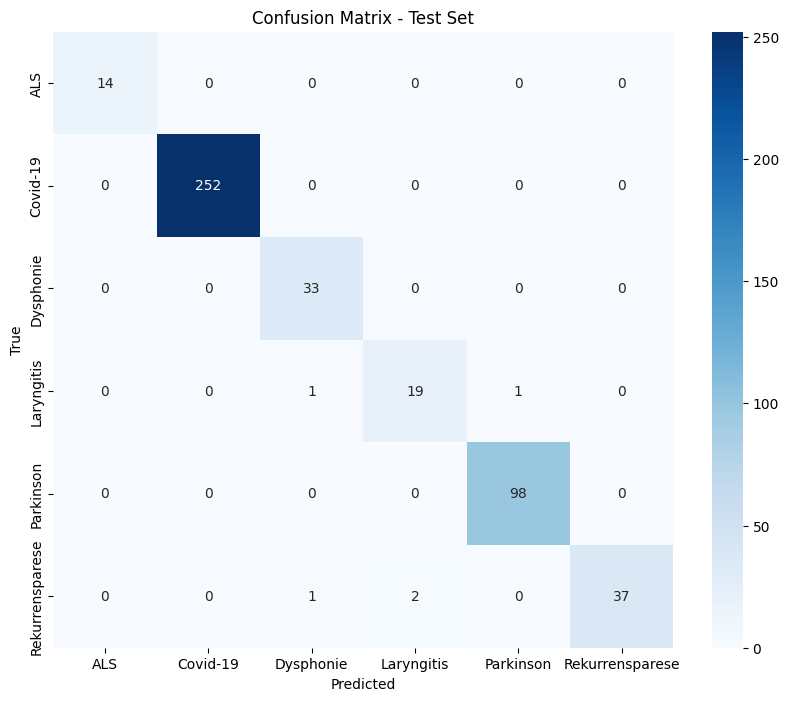

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model_on_test_set(model, test_loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            predictions = torch.argmax(outputs, axis=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    mcc = matthews_corrcoef(y_true, y_pred)

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix - Test Set")
    plt.show()

    return precision, recall, f1, mcc

final_model.load_state_dict(torch.load('/content/MA/best_resnet50_MP_model.pth'))
final_model.to(device)

precision, recall, f1, mcc = evaluate_model_on_test_set(final_model, test_loader)

In [ ]:
## classifier FP training

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet50_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

base_path = '/content/MA'
output_dir = base_path

# Class Mapping
classes = {
    "ALS": 0,
    "Covid-19": 1,
    "Dysphonie": 2,
    "Laryngitis": 3,
    "Parkinson": 4,
    "Rekurrensparese": 5
}

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32)
        if mel.ndim == 2:
            mel = mel.unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

# Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes=7):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

train_set_path = os.path.join(base_path, "train_set.xlsx")
test_set_path = os.path.join(base_path, "test_set.xlsx")
train_df = pd.read_excel(train_set_path)
test_df = pd.read_excel(test_set_path)

def filter_mp_group(df):
    filtered_df = df[(df['Group'] == 'FP') & (df['Pathology'] != 'HC')]
    if filtered_df.empty:
        raise ValueError("No valid samples found after filtering for Group=FP and excluding HC.")
    return filtered_df

filtered_train_df = filter_mp_group(train_df)
filtered_test_df = filter_mp_group(test_df)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        pathology = row['Pathology']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and pathology in classes:
            files.append(full_path)
            labels.append(classes[pathology])
        else:
            print(f"Warning: File {full_path} does not exist or invalid pathology.")
    return files, labels

train_files, train_labels = get_file_paths_and_labels(filtered_train_df, base_path)
test_files, test_labels = get_file_paths_and_labels(filtered_test_df, base_path)

print(f"Filtered training samples: {len(train_files)}")
print(f"Filtered testing samples: {len(test_files)}")

test_dataset = MelDataset(test_files, test_labels)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

def plot_loss(train_losses, val_losses, fold):
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Train vs Validation Loss - Fold {fold}")
    plt.legend()
    plt.savefig(os.path.join(output_dir, f"loss_curve_fold_{fold}.png"))
    plt.close()

def save_metrics(metrics, fold):
    metrics_df = pd.DataFrame(metrics, columns=["Epoch", "MCC"])
    metrics_df.to_csv(os.path.join(output_dir, f"validation_metrics_fold_{fold}.csv"), index=False)

def save_test_metrics(fold, mcc):
    test_results_path = os.path.join(output_dir, "test_metrics_FP.csv")
    if not os.path.exists(test_results_path):
        with open(test_results_path, "w") as f:
            f.write("Fold,MCC\n")
    with open(test_results_path, "a") as f:
        f.write(f"{fold},{mcc:.4f}\n")

def evaluate_on_test_set(model, test_loader, fold):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Test Set (Fold {fold})")
    plt.savefig(os.path.join(output_dir, f"test_confusion_FP_matrix_fold_{fold}.png"))
    plt.close()

    mcc = matthews_corrcoef(y_true, y_pred)
    print(f"Test Set Results - Fold {fold}: MCC: {mcc:.4f}")
    save_test_metrics(fold, mcc)

batch_sizes = [32, 64]
learning_rates = [1e-3, 1e-4, 1e-5]
param_combinations = list(itertools.product(batch_sizes, learning_rates))
print("Hyperparameter combinations:")
for combo in param_combinations:
    print(combo)

best_params = None
best_model = None
best_val_mcc = -1

cv_results = []

for batch_size, lr in param_combinations:
    print(f"Testing parameter combination: batch_size={batch_size}, lr={lr}")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
    fold = 1
    fold_metrics = []

    for train_idx, val_idx in skf.split(train_files, train_labels):
        print(f"Starting Fold {fold} with batch_size={batch_size}, lr={lr}")

        train_dataset = MelDataset([train_files[i] for i in train_idx], [train_labels[i] for i in train_idx])
        val_dataset = MelDataset([train_files[i] for i in val_idx], [train_labels[i] for i in val_idx])
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        model = ResNet50Classifier(num_classes=len(classes)).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        train_losses, val_losses = [], []

        for epoch in range(20):
            model.train()
            total_train_loss = 0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                total_train_loss += loss.item()

            model.eval()
            total_val_loss = 0
            y_true, y_pred = [], []
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    total_val_loss += loss.item()
                    y_true.extend(labels.cpu().numpy())
                    y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

            train_loss = total_train_loss / len(train_loader)
            val_loss = total_val_loss / len(val_loader)
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

        mcc = matthews_corrcoef(y_true, y_pred)
        fold_metrics.append(mcc)
        print(f"Fold {fold} | MCC: {mcc:.4f}")
        fold += 1

    avg_mcc = sum(fold_metrics) / len(fold_metrics)
    cv_results.append((batch_size, lr, avg_mcc))

    if avg_mcc > best_val_mcc:
        best_val_mcc = avg_mcc
        best_params = (batch_size, lr)
        best_model = model

print(f"Best parameters: batch_size={best_params[0]}, lr={best_params[1]} with MCC={best_val_mcc:.4f}")

# Retrain on whole training set
print("Retraining model with best parameters on full training set...")
final_train_dataset = MelDataset(train_files, train_labels)
final_train_loader = DataLoader(final_train_dataset, batch_size=best_params[0], shuffle=True)
final_model = ResNet50Classifier(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params[1])

for epoch in range(20):
    final_model.train()
    total_train_loss = 0
    for inputs, labels in final_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = final_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(final_train_loader)
    print(f"Retrain Epoch {epoch + 1}: Train Loss: {avg_train_loss:.4f}")

model_save_path = os.path.join(output_dir, "best_resnet50_FP_model.pth")
torch.save(final_model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

print("Evaluating final model on test set...")
evaluate_on_test_set(final_model, test_loader, "Final")


Using device: cuda
Filtered training samples: 1659
Filtered testing samples: 394
Hyperparameter combinations:
(32, 0.001)
(32, 0.0001)
(32, 1e-05)
(64, 0.001)
(64, 0.0001)
(64, 1e-05)
Testing parameter combination: batch_size=32, lr=0.001
Starting Fold 1 with batch_size=32, lr=0.001
Epoch 1: Train Loss: 0.6344, Validation Loss: 0.6317
Epoch 2: Train Loss: 0.4207, Validation Loss: 0.4644
Epoch 3: Train Loss: 0.3763, Validation Loss: 0.3528
Epoch 4: Train Loss: 0.2957, Validation Loss: 0.3952
Epoch 5: Train Loss: 0.3116, Validation Loss: 0.3327
Epoch 6: Train Loss: 0.2782, Validation Loss: 0.6179
Epoch 7: Train Loss: 0.2694, Validation Loss: 0.6568
Epoch 8: Train Loss: 0.2177, Validation Loss: 0.6949
Epoch 9: Train Loss: 0.3490, Validation Loss: 0.3969
Epoch 10: Train Loss: 0.2418, Validation Loss: 0.3531
Epoch 11: Train Loss: 0.2065, Validation Loss: 0.4161
Epoch 12: Train Loss: 0.1537, Validation Loss: 0.3011
Epoch 13: Train Loss: 0.1425, Validation Loss: 0.3312
Epoch 14: Train Loss: 0

In [ ]:
### classifier FP test

<ipython-input-8-193dd2f226d0>:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_model.load_state_dict(torch.load('/content/MA/best_resnet50_FP_model.pth'))


Precision: 0.9775
Recall: 0.9772
F1 Score: 0.9770
MCC: 0.9696


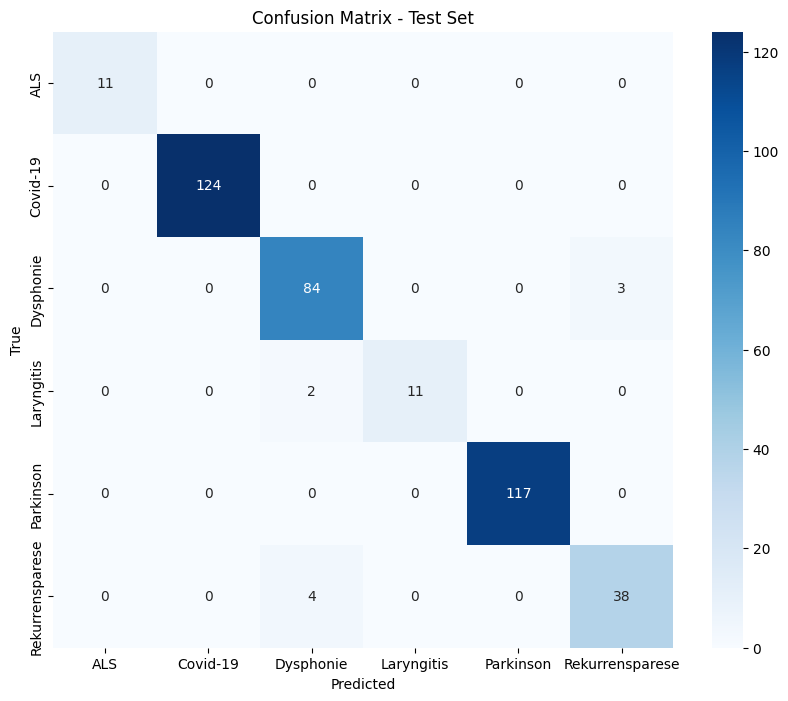

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model_on_test_set(model, test_loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            predictions = torch.argmax(outputs, axis=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    mcc = matthews_corrcoef(y_true, y_pred)

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix - Test Set")
    plt.show()

    return precision, recall, f1, mcc

final_model.load_state_dict(torch.load('/content/MA/best_resnet50_FP_model.pth'))
final_model.to(device)

precision, recall, f1, mcc = evaluate_model_on_test_set(final_model, test_loader)

In [ ]:
### two stage architecture test

Using device: cuda


<ipython-input-9-c5a47238f324>:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=device)


Total samples: 2702
Samples classified as HC: 1842
Precision: 0.9635
Recall: 0.9634
F1 Score: 0.9634
MCC: 0.9273


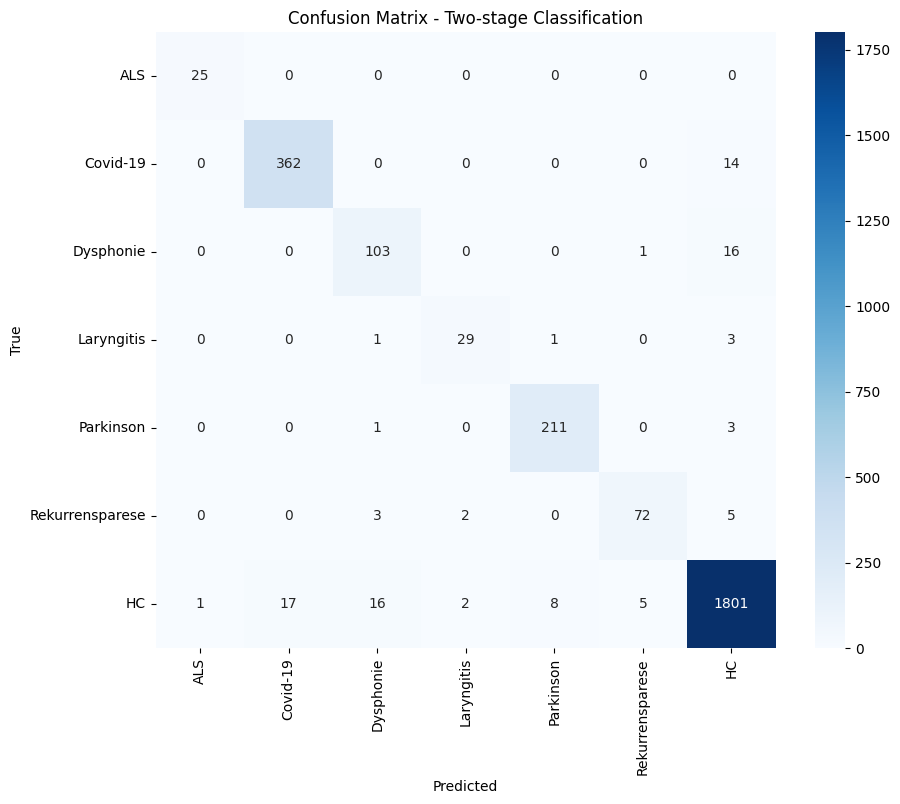

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import random
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import matthews_corrcoef, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import models
from torchvision.models import ResNet50_Weights

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Class Mapping
group_classes = {"MC": 0, "MP": 1, "FC": 2, "FP": 3}
disease_classes = {
    "ALS": 0,
    "Covid-19": 1,
    "Dysphonie": 2,
    "Laryngitis": 3,
    "Parkinson": 4,
    "Rekurrensparese": 5,
    "HC": 6
}

# Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

def load_model(model_path, num_classes):
    model = ResNet50Classifier(num_classes=num_classes).to(device)
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    return model

def get_test_loader(test_files, test_labels, batch_size=32):
    test_dataset = MelDataset(test_files, test_labels)
    return DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Load Group Classifier
group_model = load_model("/content/MA/final_group_classifier.pth", num_classes=4)

# Load MP and FP Classifier
mp_model = load_model("/content/MA/best_resnet50_MP_model.pth", num_classes=6)
fp_model = load_model("/content/MA/best_resnet50_FP_model.pth", num_classes=6)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        pathology = row['Pathology']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and pathology in disease_classes:
            files.append(full_path)
            labels.append(disease_classes[pathology])
        else:
            print(f"Warning: File {full_path} does not exist or invalid pathology.")
    return files, labels

test_set_path = os.path.join("/content/MA", "test_set.xlsx")
test_df = pd.read_excel(test_set_path)
test_files, test_labels = get_file_paths_and_labels(test_df, "/content/MA")

test_loader = get_test_loader(test_files, test_labels)

y_true, y_pred = [], []

total_samples, mc_fc_count = 0, 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.numpy()
        if len(inputs.shape) == 5:
            inputs = inputs.squeeze(2)
        group_outputs = group_model(inputs)
        group_preds = torch.argmax(group_outputs, axis=1).cpu().numpy()

        for i, group_pred in enumerate(group_preds):
            if group_pred in [group_classes["MC"], group_classes["FC"]]:
                y_true.append(labels[i])
                y_pred.append(disease_classes["HC"])
                mc_fc_count += 1
            elif group_pred == group_classes["MP"]:
                mp_output = mp_model(inputs[i].unsqueeze(0))
                mp_pred = torch.argmax(mp_output, axis=1).cpu().item()
                y_true.append(labels[i])
                y_pred.append(mp_pred)
            elif group_pred == group_classes["FP"]:
                fp_output = fp_model(inputs[i].unsqueeze(0))
                fp_pred = torch.argmax(fp_output, axis=1).cpu().item()
                y_true.append(labels[i])
                y_pred.append(fp_pred)

print(f"Total samples: {len(test_labels)}")
print(f"Samples classified as HC: {mc_fc_count}")

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
mcc = matthews_corrcoef(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=disease_classes.keys(),
            yticklabels=disease_classes.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Two-stage Classification")
plt.show()


In [ ]:
### EXP 3.1 Resampling Augmentation based two stage architecture

In [ ]:
### classifier PD training

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet50_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

base_path = '/content/MA'
output_dir = base_path

# Class Mapping
classes = {
    "MC": 0,  # Male Control
    "MP": 1,  # Male Pathology
    "FC": 2,  # Female Control
    "FP": 3   # Female Pathology
}

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32)
        if mel.ndim == 2:
            mel = mel.unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

# Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes=4):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        group = row['Group']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and group in classes:
            files.append(full_path)
            labels.append(classes[group])
        else:
            print(f"Warning: File {full_path} does not exist or invalid group.")
    return files, labels

train_set_path = os.path.join(base_path, "train_set.xlsx")
test_set_path = os.path.join(base_path, "test_set.xlsx")
train_df = pd.read_excel(train_set_path)
test_df = pd.read_excel(test_set_path)

train_files, train_labels = get_file_paths_and_labels(train_df, base_path)
test_files, test_labels = get_file_paths_and_labels(test_df, base_path)

test_dataset = MelDataset(test_files, test_labels)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

def plot_loss(train_losses, val_losses, fold):
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Train vs Validation Loss - Fold {fold}")
    plt.legend()
    plt.savefig(os.path.join(output_dir, f"loss_curve_fold_{fold}.png"))
    plt.close()

def save_metrics(metrics, fold):
    metrics_df = pd.DataFrame(metrics, columns=["Epoch", "MCC"])
    metrics_df.to_csv(os.path.join(output_dir, f"validation_metrics_fold_{fold}.csv"), index=False)

def save_test_metrics(fold, mcc):
    test_results_path = os.path.join(output_dir, "test_metrics.csv")
    if not os.path.exists(test_results_path):
        with open(test_results_path, "w") as f:
            f.write("Fold,MCC\n")
    with open(test_results_path, "a") as f:
        f.write(f"{fold},{mcc:.4f}\n")

def evaluate_on_test_set(model, test_loader, fold):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Test Set (Fold {fold})")
    plt.savefig(os.path.join(output_dir, f"test_confusion_matrix_fold_{fold}.png"))
    plt.close()

    mcc = matthews_corrcoef(y_true, y_pred)
    print(f"Test Set Results - Fold {fold}: MCC: {mcc:.4f}")
    save_test_metrics(fold, mcc)

batch_sizes = [32, 64]
learning_rates = [1e-3, 1e-4, 1e-5]
param_combinations = list(itertools.product(batch_sizes, learning_rates))

best_params = None
best_model = None
best_val_mcc = -1

cv_results = []

for batch_size, lr in param_combinations:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
    fold = 1

    last_mcc_values = []

    for train_idx, val_idx in skf.split(train_files, train_labels):
        print(f"Starting Fold {fold} with batch_size={batch_size}, lr={lr}")

        train_dataset = MelDataset([train_files[i] for i in train_idx], [train_labels[i] for i in train_idx])
        val_dataset = MelDataset([train_files[i] for i in val_idx], [train_labels[i] for i in val_idx])
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        model = ResNet50Classifier(num_classes=len(classes)).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        train_losses, val_losses = [], []

        for epoch in range(20):
            model.train()
            total_train_loss = 0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                total_train_loss += loss.item()

            model.eval()
            total_val_loss = 0
            y_true, y_pred = [], []
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    total_val_loss += loss.item()
                    y_true.extend(labels.cpu().numpy())
                    y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

            train_loss = total_train_loss / len(train_loader)
            val_loss = total_val_loss / len(val_loader)
            train_losses.append(train_loss)
            val_losses.append(val_loss)

            print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

        last_mcc = matthews_corrcoef(y_true, y_pred)
        last_mcc_values.append(last_mcc)
        print(f"Fold {fold} | MCC: {last_mcc:.4f}")
        fold += 1

    avg_mcc = np.mean(last_mcc_values)
    print(f"Average MCC for batch_size={batch_size}, lr={lr}: {avg_mcc:.4f}")

    if avg_mcc > best_val_mcc:
        best_val_mcc = avg_mcc
        best_params = (batch_size, lr)
        best_model = model

print(f"Best Parameters: batch_size={best_params[0]}, lr={best_params[1]} with MCC={best_val_mcc:.4f}")

# Retrain on whole training set
final_train_dataset = MelDataset(train_files, train_labels)
final_train_loader = DataLoader(final_train_dataset, batch_size=best_params[0], shuffle=True)
final_model = ResNet50Classifier(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params[1])

train_losses = []

for epoch in range(20):
    final_model.train()
    total_train_loss = 0
    for inputs, labels in final_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = final_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(final_train_loader)
    train_losses.append(avg_train_loss)
    print(f"Retrain Epoch {epoch + 1}: Train Loss: {avg_train_loss:.4f}")

final_model_save_path = os.path.join(output_dir, "final_group_classifier.pth")
torch.save(final_model.state_dict(), final_model_save_path)
print(f"Final model saved to {final_model_save_path}")

final_model.load_state_dict(torch.load(final_model_save_path))
evaluate_on_test_set(final_model, test_loader, "Final")


Using device: cuda
Starting Fold 1 with batch_size=32, lr=0.001


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s]


Epoch 1: Train Loss: 0.7321, Validation Loss: 0.6673
Epoch 2: Train Loss: 0.4737, Validation Loss: 0.4290
Epoch 3: Train Loss: 0.3175, Validation Loss: 0.3162
Epoch 4: Train Loss: 0.2239, Validation Loss: 0.1984
Epoch 5: Train Loss: 0.1651, Validation Loss: 0.2316
Epoch 6: Train Loss: 0.1275, Validation Loss: 0.1328
Epoch 7: Train Loss: 0.1050, Validation Loss: 0.1427
Epoch 8: Train Loss: 0.0826, Validation Loss: 0.1036
Epoch 9: Train Loss: 0.0804, Validation Loss: 0.0696
Epoch 10: Train Loss: 0.0526, Validation Loss: 0.1522
Epoch 11: Train Loss: 0.0614, Validation Loss: 0.1036
Epoch 12: Train Loss: 0.0636, Validation Loss: 0.1278
Epoch 13: Train Loss: 0.0370, Validation Loss: 0.1718
Epoch 14: Train Loss: 0.0571, Validation Loss: 0.1869
Epoch 15: Train Loss: 0.0257, Validation Loss: 0.0936
Epoch 16: Train Loss: 0.0451, Validation Loss: 0.1115
Epoch 17: Train Loss: 0.0369, Validation Loss: 0.1300
Epoch 18: Train Loss: 0.0333, Validation Loss: 0.0913
Epoch 19: Train Loss: 0.0354, Validat

<ipython-input-2-724506df6f05>:257: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_model.load_state_dict(torch.load(final_model_save_path))


Test Set Results - Fold Final: MCC: 0.9536


In [ ]:
## classifier PD test

<ipython-input-3-99cc715392d4>:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_model.load_state_dict(torch.load('/content/MA/final_group_classifier.pth'))


Precision: 0.9681
Recall: 0.9682
F1 Score: 0.9680
MCC: 0.9536


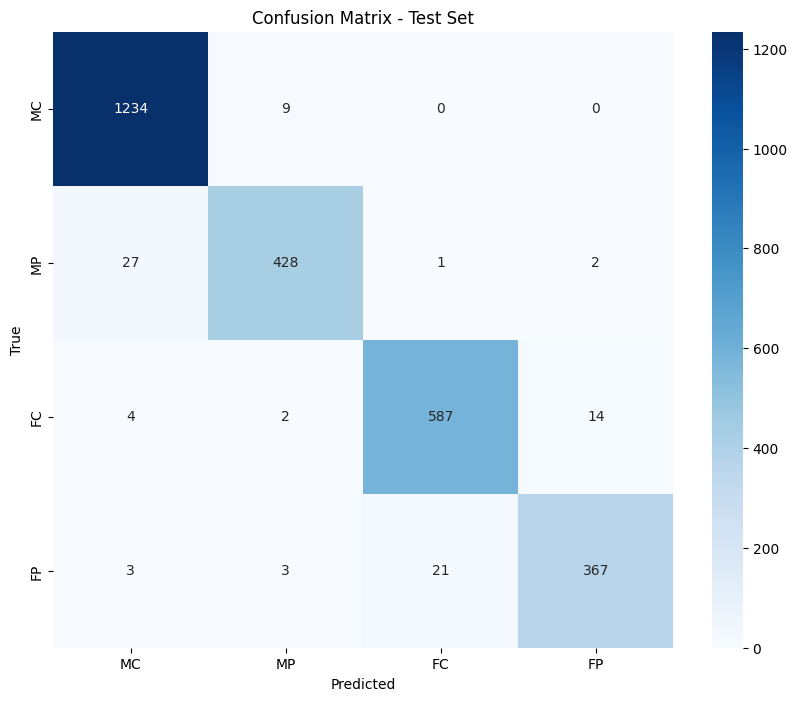

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model_on_test_set(model, test_loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            predictions = torch.argmax(outputs, axis=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    mcc = matthews_corrcoef(y_true, y_pred)

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix - Test Set")
    plt.show()

    return precision, recall, f1, mcc

final_model.load_state_dict(torch.load('/content/MA/final_group_classifier.pth'))
final_model.to(device)

precision, recall, f1, mcc = evaluate_model_on_test_set(final_model, test_loader)


In [ ]:
### classifier MP training

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet50_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

base_path = '/content/MA'
output_dir = base_path

# Class Mapping
classes = {
    "ALS": 0,
    "Covid-19": 1,
    "Dysphonie": 2,
    "Laryngitis": 3,
    "Parkinson": 4,
    "Rekurrensparese": 5
}

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32)
        if mel.ndim == 2:
            mel = mel.unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

# Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes=7):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

train_set_path = os.path.join(base_path, "train_set.xlsx")
test_set_path = os.path.join(base_path, "test_set.xlsx")
train_df = pd.read_excel(train_set_path)
test_df = pd.read_excel(test_set_path)

def filter_mp_group(df):
    filtered_df = df[(df['Group'] == 'MP') & (df['Pathology'] != 'HC')]
    if filtered_df.empty:
        raise ValueError("No valid samples found after filtering for Group=MP and excluding HC.")
    return filtered_df

filtered_train_df = filter_mp_group(train_df)
filtered_test_df = filter_mp_group(test_df)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        pathology = row['Pathology']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and pathology in classes:
            files.append(full_path)
            labels.append(classes[pathology])
        else:
            print(f"Warning: File {full_path} does not exist or invalid pathology.")
    return files, labels

train_files, train_labels = get_file_paths_and_labels(filtered_train_df, base_path)
test_files, test_labels = get_file_paths_and_labels(filtered_test_df, base_path)

print(f"Filtered training samples: {len(train_files)}")
print(f"Filtered testing samples: {len(test_files)}")

test_dataset = MelDataset(test_files, test_labels)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

def plot_loss(train_losses, val_losses, fold):
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Train vs Validation Loss - Fold {fold}")
    plt.legend()
    plt.savefig(os.path.join(output_dir, f"loss_curve_fold_{fold}.png"))
    plt.close()

def save_metrics(metrics, fold):
    metrics_df = pd.DataFrame(metrics, columns=["Epoch", "MCC"])
    metrics_df.to_csv(os.path.join(output_dir, f"validation_metrics_fold_{fold}.csv"), index=False)

def save_test_metrics(fold, mcc):
    test_results_path = os.path.join(output_dir, "test_metrics_MP.csv")
    if not os.path.exists(test_results_path):
        with open(test_results_path, "w") as f:
            f.write("Fold,MCC\n")
    with open(test_results_path, "a") as f:
        f.write(f"{fold},{mcc:.4f}\n")

def evaluate_on_test_set(model, test_loader, fold):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Test Set (Fold {fold})")
    plt.savefig(os.path.join(output_dir, f"test_confusion_MP_matrix_fold_{fold}.png"))
    plt.close()

    mcc = matthews_corrcoef(y_true, y_pred)
    print(f"Test Set Results - Fold {fold}: MCC: {mcc:.4f}")
    save_test_metrics(fold, mcc)

batch_sizes = [32, 64]
learning_rates = [1e-3, 1e-4, 1e-5]
param_combinations = list(itertools.product(batch_sizes, learning_rates))
print("Hyperparameter combinations:")
for combo in param_combinations:
    print(combo)

best_params = None
best_model = None
best_val_mcc = -1

cv_results = []

for batch_size, lr in param_combinations:
    print(f"Testing parameter combination: batch_size={batch_size}, lr={lr}")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
    fold = 1
    fold_metrics = []

    for train_idx, val_idx in skf.split(train_files, train_labels):
        print(f"Starting Fold {fold} with batch_size={batch_size}, lr={lr}")

        train_dataset = MelDataset([train_files[i] for i in train_idx], [train_labels[i] for i in train_idx])
        val_dataset = MelDataset([train_files[i] for i in val_idx], [train_labels[i] for i in val_idx])
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        model = ResNet50Classifier(num_classes=len(classes)).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        train_losses, val_losses = [], []

        for epoch in range(20):
            model.train()
            total_train_loss = 0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                total_train_loss += loss.item()

            model.eval()
            total_val_loss = 0
            y_true, y_pred = [], []
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    total_val_loss += loss.item()
                    y_true.extend(labels.cpu().numpy())
                    y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

            train_loss = total_train_loss / len(train_loader)
            val_loss = total_val_loss / len(val_loader)
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

        mcc = matthews_corrcoef(y_true, y_pred)
        fold_metrics.append(mcc)
        print(f"Fold {fold} | MCC: {mcc:.4f}")
        fold += 1

    avg_mcc = sum(fold_metrics) / len(fold_metrics)
    cv_results.append((batch_size, lr, avg_mcc))

    if avg_mcc > best_val_mcc:
        best_val_mcc = avg_mcc
        best_params = (batch_size, lr)
        best_model = model

print(f"Best parameters: batch_size={best_params[0]}, lr={best_params[1]} with MCC={best_val_mcc:.4f}")

# Retrain on whole training set
print("Retraining model with best parameters on full training set...")
final_train_dataset = MelDataset(train_files, train_labels)
final_train_loader = DataLoader(final_train_dataset, batch_size=best_params[0], shuffle=True)
final_model = ResNet50Classifier(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params[1])

for epoch in range(20):
    final_model.train()
    total_train_loss = 0
    for inputs, labels in final_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = final_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(final_train_loader)
    print(f"Retrain Epoch {epoch + 1}: Train Loss: {avg_train_loss:.4f}")

model_save_path = os.path.join(output_dir, "best_resnet50_MP_model.pth")
torch.save(final_model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

print("Evaluating final model on test set...")
evaluate_on_test_set(final_model, test_loader, "Final")


Using device: cuda
Filtered training samples: 5589
Filtered testing samples: 458
Hyperparameter combinations:
(32, 0.001)
(32, 0.0001)
(32, 1e-05)
(64, 0.001)
(64, 0.0001)
(64, 1e-05)
Testing parameter combination: batch_size=32, lr=0.001
Starting Fold 1 with batch_size=32, lr=0.001
Epoch 1: Train Loss: 0.6363, Validation Loss: 0.3889
Epoch 2: Train Loss: 0.3706, Validation Loss: 0.3473
Epoch 3: Train Loss: 0.2086, Validation Loss: 0.2186
Epoch 4: Train Loss: 0.1862, Validation Loss: 0.1506
Epoch 5: Train Loss: 0.1188, Validation Loss: 0.1249
Epoch 6: Train Loss: 0.1121, Validation Loss: 0.1289
Epoch 7: Train Loss: 0.0774, Validation Loss: 0.2324
Epoch 8: Train Loss: 0.0411, Validation Loss: 0.0958
Epoch 9: Train Loss: 0.0444, Validation Loss: 0.0835
Epoch 10: Train Loss: 0.0502, Validation Loss: 0.1786
Epoch 11: Train Loss: 0.0639, Validation Loss: 0.0603
Epoch 12: Train Loss: 0.0186, Validation Loss: 0.0434
Epoch 13: Train Loss: 0.0295, Validation Loss: 0.1091
Epoch 14: Train Loss: 0

In [ ]:
### classifier MP test

<ipython-input-4-5a625e53b0fb>:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_model.load_state_dict(torch.load('/content/MA/best_resnet50_MP_model.pth'))


Precision: 0.9868
Recall: 0.9869
F1 Score: 0.9868
MCC: 0.9794


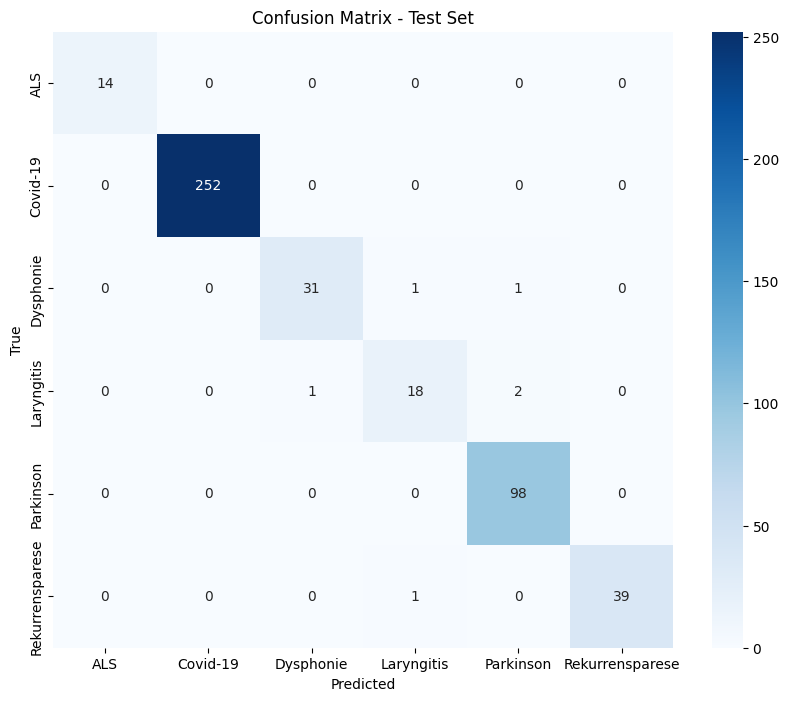

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model_on_test_set(model, test_loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            predictions = torch.argmax(outputs, axis=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    mcc = matthews_corrcoef(y_true, y_pred)

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix - Test Set")
    plt.show()

    return precision, recall, f1, mcc

final_model.load_state_dict(torch.load('/content/MA/best_resnet50_MP_model.pth'))
final_model.to(device)

precision, recall, f1, mcc = evaluate_model_on_test_set(final_model, test_loader)

In [ ]:
## classifier FP training

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet50_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import itertools


random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

base_path = '/content/MA'
output_dir = base_path

# Class Mapping
classes = {
    "ALS": 0,
    "Covid-19": 1,
    "Dysphonie": 2,
    "Laryngitis": 3,
    "Parkinson": 4,
    "Rekurrensparese": 5
}

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32)
        if mel.ndim == 2:
            mel = mel.unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

# Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes=7):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

train_set_path = os.path.join(base_path, "train_set.xlsx")
test_set_path = os.path.join(base_path, "test_set.xlsx")
train_df = pd.read_excel(train_set_path)
test_df = pd.read_excel(test_set_path)

def filter_mp_group(df):
    filtered_df = df[(df['Group'] == 'FP') & (df['Pathology'] != 'HC')]
    if filtered_df.empty:
        raise ValueError("No valid samples found after filtering for Group=FP and excluding HC.")
    return filtered_df

filtered_train_df = filter_mp_group(train_df)
filtered_test_df = filter_mp_group(test_df)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        pathology = row['Pathology']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and pathology in classes:
            files.append(full_path)
            labels.append(classes[pathology])
        else:
            print(f"Warning: File {full_path} does not exist or invalid pathology.")
    return files, labels

train_files, train_labels = get_file_paths_and_labels(filtered_train_df, base_path)
test_files, test_labels = get_file_paths_and_labels(filtered_test_df, base_path)

print(f"Filtered training samples: {len(train_files)}")
print(f"Filtered testing samples: {len(test_files)}")

test_dataset = MelDataset(test_files, test_labels)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

def plot_loss(train_losses, val_losses, fold):
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Train vs Validation Loss - Fold {fold}")
    plt.legend()
    plt.savefig(os.path.join(output_dir, f"loss_curve_fold_{fold}.png"))
    plt.close()

def save_metrics(metrics, fold):
    metrics_df = pd.DataFrame(metrics, columns=["Epoch", "MCC"])
    metrics_df.to_csv(os.path.join(output_dir, f"validation_metrics_fold_{fold}.csv"), index=False)

def save_test_metrics(fold, mcc):
    test_results_path = os.path.join(output_dir, "test_metrics_FP.csv")
    if not os.path.exists(test_results_path):
        with open(test_results_path, "w") as f:
            f.write("Fold,MCC\n")
    with open(test_results_path, "a") as f:
        f.write(f"{fold},{mcc:.4f}\n")

def evaluate_on_test_set(model, test_loader, fold):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Test Set (Fold {fold})")
    plt.savefig(os.path.join(output_dir, f"test_confusion_FP_matrix_fold_{fold}.png"))
    plt.close()

    mcc = matthews_corrcoef(y_true, y_pred)
    print(f"Test Set Results - Fold {fold}: MCC: {mcc:.4f}")
    save_test_metrics(fold, mcc)

batch_sizes = [32, 64]
learning_rates = [1e-3, 1e-4, 1e-5]
param_combinations = list(itertools.product(batch_sizes, learning_rates))
print("Hyperparameter combinations:")
for combo in param_combinations:
    print(combo)

best_params = None
best_model = None
best_val_mcc = -1

cv_results = []

for batch_size, lr in param_combinations:
    print(f"Testing parameter combination: batch_size={batch_size}, lr={lr}")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
    fold = 1
    fold_metrics = []

    for train_idx, val_idx in skf.split(train_files, train_labels):
        print(f"Starting Fold {fold} with batch_size={batch_size}, lr={lr}")

        train_dataset = MelDataset([train_files[i] for i in train_idx], [train_labels[i] for i in train_idx])
        val_dataset = MelDataset([train_files[i] for i in val_idx], [train_labels[i] for i in val_idx])
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        model = ResNet50Classifier(num_classes=len(classes)).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        train_losses, val_losses = [], []

        for epoch in range(20):
            model.train()
            total_train_loss = 0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                total_train_loss += loss.item()

            model.eval()
            total_val_loss = 0
            y_true, y_pred = [], []
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    total_val_loss += loss.item()
                    y_true.extend(labels.cpu().numpy())
                    y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

            train_loss = total_train_loss / len(train_loader)
            val_loss = total_val_loss / len(val_loader)
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

        mcc = matthews_corrcoef(y_true, y_pred)
        fold_metrics.append(mcc)
        print(f"Fold {fold} | MCC: {mcc:.4f}")
        fold += 1

    avg_mcc = sum(fold_metrics) / len(fold_metrics)
    cv_results.append((batch_size, lr, avg_mcc))

    if avg_mcc > best_val_mcc:
        best_val_mcc = avg_mcc
        best_params = (batch_size, lr)
        best_model = model

print(f"Best parameters: batch_size={best_params[0]}, lr={best_params[1]} with MCC={best_val_mcc:.4f}")

# Retrain on whole training set
print("Retraining model with best parameters on full training set...")
final_train_dataset = MelDataset(train_files, train_labels)
final_train_loader = DataLoader(final_train_dataset, batch_size=best_params[0], shuffle=True)
final_model = ResNet50Classifier(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params[1])

for epoch in range(20):
    final_model.train()
    total_train_loss = 0
    for inputs, labels in final_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = final_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(final_train_loader)
    print(f"Retrain Epoch {epoch + 1}: Train Loss: {avg_train_loss:.4f}")

model_save_path = os.path.join(output_dir, "best_resnet50_FP_model.pth")
torch.save(final_model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

print("Evaluating final model on test set...")
evaluate_on_test_set(final_model, test_loader, "Final")


Using device: cuda
Filtered training samples: 3424
Filtered testing samples: 394
Hyperparameter combinations:
(32, 0.001)
(32, 0.0001)
(32, 1e-05)
(64, 0.001)
(64, 0.0001)
(64, 1e-05)
Testing parameter combination: batch_size=32, lr=0.001
Starting Fold 1 with batch_size=32, lr=0.001


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 195MB/s]


Epoch 1: Train Loss: 0.7106, Validation Loss: 0.7571
Epoch 2: Train Loss: 0.5571, Validation Loss: 0.6184
Epoch 3: Train Loss: 0.3677, Validation Loss: 0.3563
Epoch 4: Train Loss: 0.3022, Validation Loss: 0.6767
Epoch 5: Train Loss: 0.3338, Validation Loss: 0.4091
Epoch 6: Train Loss: 0.2333, Validation Loss: 0.4061
Epoch 7: Train Loss: 0.1644, Validation Loss: 0.2874
Epoch 8: Train Loss: 0.2021, Validation Loss: 0.2124
Epoch 9: Train Loss: 0.1723, Validation Loss: 0.1739
Epoch 10: Train Loss: 0.1331, Validation Loss: 0.1814
Epoch 11: Train Loss: 0.0917, Validation Loss: 0.1570
Epoch 12: Train Loss: 0.0484, Validation Loss: 0.2134
Epoch 13: Train Loss: 0.0838, Validation Loss: 0.4267
Epoch 14: Train Loss: 0.0691, Validation Loss: 0.1826
Epoch 15: Train Loss: 0.0530, Validation Loss: 0.0983
Epoch 16: Train Loss: 0.0398, Validation Loss: 0.2043
Epoch 17: Train Loss: 0.0546, Validation Loss: 0.2227
Epoch 18: Train Loss: 0.0824, Validation Loss: 0.1727
Epoch 19: Train Loss: 0.0330, Validat

In [ ]:
### classifier FP test

<ipython-input-4-193dd2f226d0>:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_model.load_state_dict(torch.load('/content/MA/best_resnet50_FP_model.pth'))


Precision: 0.9628
Recall: 0.9619
F1 Score: 0.9618
MCC: 0.9493


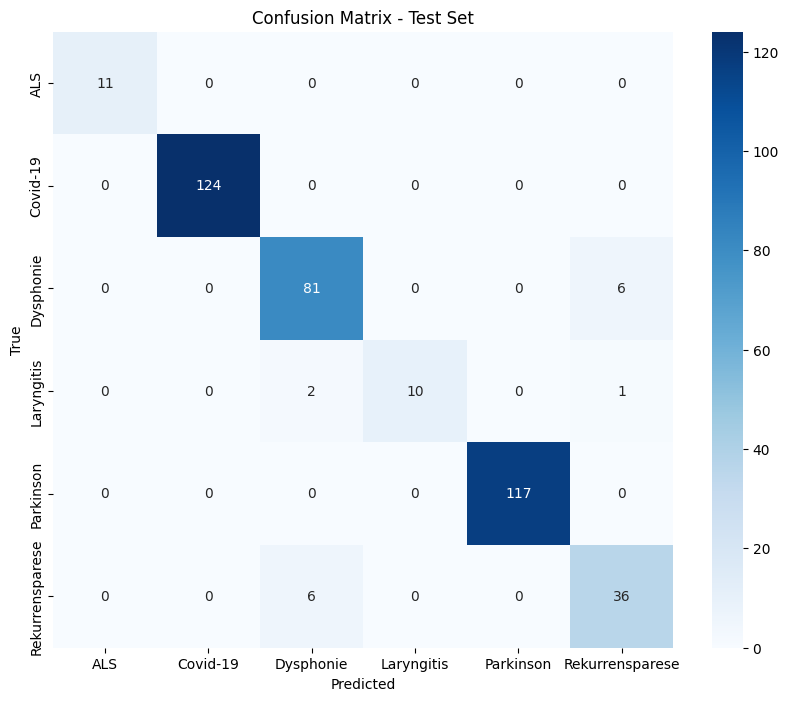

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model_on_test_set(model, test_loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            predictions = torch.argmax(outputs, axis=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    mcc = matthews_corrcoef(y_true, y_pred)

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix - Test Set")
    plt.show()

    return precision, recall, f1, mcc

final_model.load_state_dict(torch.load('/content/MA/best_resnet50_FP_model.pth'))
final_model.to(device)

precision, recall, f1, mcc = evaluate_model_on_test_set(final_model, test_loader)

In [ ]:
### two stage architecture test

Using device: cuda


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 130MB/s]
<ipython-input-2-c5a47238f324>:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded

Total samples: 2702
Samples classified as HC: 1875
Precision: 0.9668
Recall: 0.9671
F1 Score: 0.9666
MCC: 0.9339


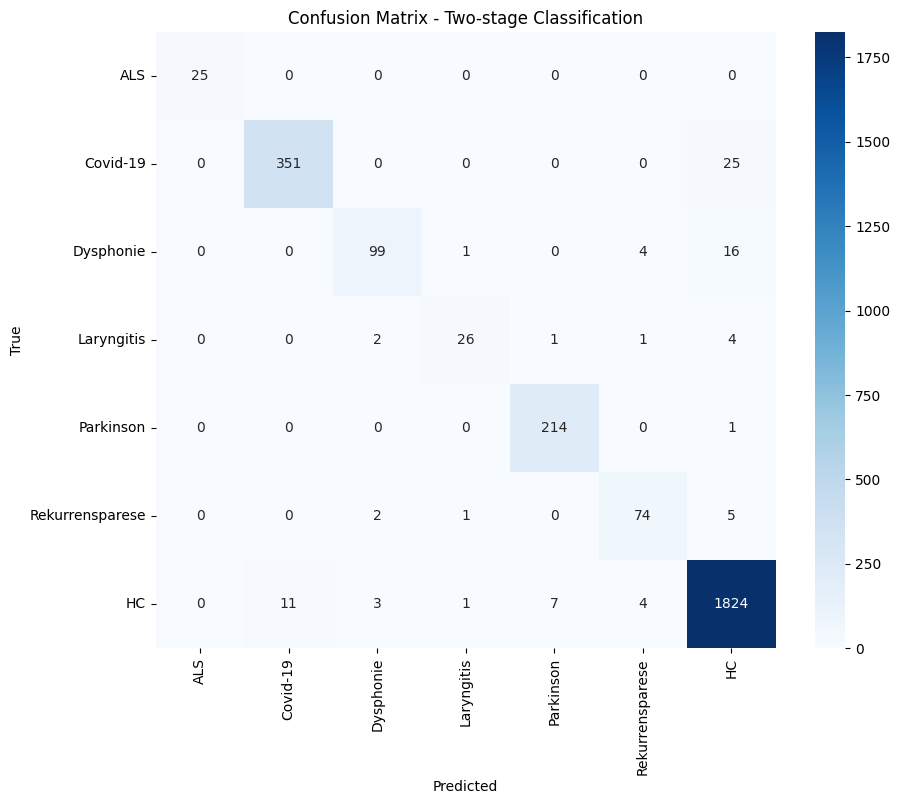

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import random
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import matthews_corrcoef, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import models
from torchvision.models import ResNet50_Weights

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Class Mapping
group_classes = {"MC": 0, "MP": 1, "FC": 2, "FP": 3}
disease_classes = {
    "ALS": 0,
    "Covid-19": 1,
    "Dysphonie": 2,
    "Laryngitis": 3,
    "Parkinson": 4,
    "Rekurrensparese": 5,
    "HC": 6
}

# Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

def load_model(model_path, num_classes):
    model = ResNet50Classifier(num_classes=num_classes).to(device)
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    return model

def get_test_loader(test_files, test_labels, batch_size=32):
    test_dataset = MelDataset(test_files, test_labels)
    return DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Load Group Classifier
group_model = load_model("/content/MA/final_group_classifier.pth", num_classes=4)

# Load MP and FP Classifier
mp_model = load_model("/content/MA/best_resnet50_MP_model.pth", num_classes=6)
fp_model = load_model("/content/MA/best_resnet50_FP_model.pth", num_classes=6)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        pathology = row['Pathology']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and pathology in disease_classes:
            files.append(full_path)
            labels.append(disease_classes[pathology])
        else:
            print(f"Warning: File {full_path} does not exist or invalid pathology.")
    return files, labels

test_set_path = os.path.join("/content/MA", "test_set.xlsx")
test_df = pd.read_excel(test_set_path)
test_files, test_labels = get_file_paths_and_labels(test_df, "/content/MA")

test_loader = get_test_loader(test_files, test_labels)

y_true, y_pred = [], []

total_samples, mc_fc_count = 0, 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.numpy()
        if len(inputs.shape) == 5:
            inputs = inputs.squeeze(2)
        group_outputs = group_model(inputs)
        group_preds = torch.argmax(group_outputs, axis=1).cpu().numpy()

        for i, group_pred in enumerate(group_preds):
            if group_pred in [group_classes["MC"], group_classes["FC"]]:
                y_true.append(labels[i])
                y_pred.append(disease_classes["HC"])
                mc_fc_count += 1
            elif group_pred == group_classes["MP"]:
                mp_output = mp_model(inputs[i].unsqueeze(0))
                mp_pred = torch.argmax(mp_output, axis=1).cpu().item()
                y_true.append(labels[i])
                y_pred.append(mp_pred)
            elif group_pred == group_classes["FP"]:
                fp_output = fp_model(inputs[i].unsqueeze(0))
                fp_pred = torch.argmax(fp_output, axis=1).cpu().item()
                y_true.append(labels[i])
                y_pred.append(fp_pred)

print(f"Total samples: {len(test_labels)}")
print(f"Samples classified as HC: {mc_fc_count}")

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
mcc = matthews_corrcoef(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=disease_classes.keys(),
            yticklabels=disease_classes.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Two-stage Classification")
plt.show()


In [ ]:
### EXP 3.2 Timewarp based two stage architecture

In [ ]:
### classifier PD training

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet50_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

base_path = '/content/MA'
output_dir = base_path

# Class Mapping
classes = {
    "MC": 0,  # Male Control
    "MP": 1,  # Male Pathology
    "FC": 2,  # Female Control
    "FP": 3   # Female Pathology
}

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32)
        if mel.ndim == 2:
            mel = mel.unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

# Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes=4):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        group = row['Group']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and group in classes:
            files.append(full_path)
            labels.append(classes[group])
        else:
            print(f"Warning: File {full_path} does not exist or invalid group.")
    return files, labels

train_set_path = os.path.join(base_path, "train_set.xlsx")
test_set_path = os.path.join(base_path, "test_set.xlsx")
train_df = pd.read_excel(train_set_path)
test_df = pd.read_excel(test_set_path)

train_files, train_labels = get_file_paths_and_labels(train_df, base_path)
test_files, test_labels = get_file_paths_and_labels(test_df, base_path)

test_dataset = MelDataset(test_files, test_labels)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

def plot_loss(train_losses, val_losses, fold):
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Train vs Validation Loss - Fold {fold}")
    plt.legend()
    plt.savefig(os.path.join(output_dir, f"loss_curve_fold_{fold}.png"))
    plt.close()

def save_metrics(metrics, fold):
    metrics_df = pd.DataFrame(metrics, columns=["Epoch", "MCC"])
    metrics_df.to_csv(os.path.join(output_dir, f"validation_metrics_fold_{fold}.csv"), index=False)

def save_test_metrics(fold, mcc):
    test_results_path = os.path.join(output_dir, "test_metrics.csv")
    if not os.path.exists(test_results_path):
        with open(test_results_path, "w") as f:
            f.write("Fold,MCC\n")
    with open(test_results_path, "a") as f:
        f.write(f"{fold},{mcc:.4f}\n")

def evaluate_on_test_set(model, test_loader, fold):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Test Set (Fold {fold})")
    plt.savefig(os.path.join(output_dir, f"test_confusion_matrix_fold_{fold}.png"))
    plt.close()

    mcc = matthews_corrcoef(y_true, y_pred)
    print(f"Test Set Results - Fold {fold}: MCC: {mcc:.4f}")
    save_test_metrics(fold, mcc)

batch_sizes = [32, 64]
learning_rates = [1e-3, 1e-4, 1e-5]
param_combinations = list(itertools.product(batch_sizes, learning_rates))

best_params = None
best_model = None
best_val_mcc = -1

cv_results = []

for batch_size, lr in param_combinations:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
    fold = 1

    last_mcc_values = []

    for train_idx, val_idx in skf.split(train_files, train_labels):
        print(f"Starting Fold {fold} with batch_size={batch_size}, lr={lr}")

        train_dataset = MelDataset([train_files[i] for i in train_idx], [train_labels[i] for i in train_idx])
        val_dataset = MelDataset([train_files[i] for i in val_idx], [train_labels[i] for i in val_idx])
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        model = ResNet50Classifier(num_classes=len(classes)).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        train_losses, val_losses = [], []

        for epoch in range(20):
            model.train()
            total_train_loss = 0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                total_train_loss += loss.item()

            model.eval()
            total_val_loss = 0
            y_true, y_pred = [], []
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    total_val_loss += loss.item()
                    y_true.extend(labels.cpu().numpy())
                    y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

            train_loss = total_train_loss / len(train_loader)
            val_loss = total_val_loss / len(val_loader)
            train_losses.append(train_loss)
            val_losses.append(val_loss)

            print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

        last_mcc = matthews_corrcoef(y_true, y_pred)
        last_mcc_values.append(last_mcc)
        print(f"Fold {fold} | MCC: {last_mcc:.4f}")
        fold += 1

    avg_mcc = np.mean(last_mcc_values)
    print(f"Average MCC for batch_size={batch_size}, lr={lr}: {avg_mcc:.4f}")

    if avg_mcc > best_val_mcc:
        best_val_mcc = avg_mcc
        best_params = (batch_size, lr)
        best_model = model

print(f"Best Parameters: batch_size={best_params[0]}, lr={best_params[1]} with MCC={best_val_mcc:.4f}")

# Retrain on whole training set
final_train_dataset = MelDataset(train_files, train_labels)
final_train_loader = DataLoader(final_train_dataset, batch_size=best_params[0], shuffle=True)
final_model = ResNet50Classifier(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params[1])

train_losses = []

for epoch in range(20):
    final_model.train()
    total_train_loss = 0
    for inputs, labels in final_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = final_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(final_train_loader)
    train_losses.append(avg_train_loss)
    print(f"Retrain Epoch {epoch + 1}: Train Loss: {avg_train_loss:.4f}")

final_model_save_path = os.path.join(output_dir, "final_group_classifier.pth")
torch.save(final_model.state_dict(), final_model_save_path)
print(f"Final model saved to {final_model_save_path}")

final_model.load_state_dict(torch.load(final_model_save_path))
evaluate_on_test_set(final_model, test_loader, "Final")


Using device: cuda
Starting Fold 1 with batch_size=32, lr=0.001


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 227MB/s]


Epoch 1: Train Loss: 0.7024, Validation Loss: 0.5668
Epoch 2: Train Loss: 0.4635, Validation Loss: 0.4337
Epoch 3: Train Loss: 0.3351, Validation Loss: 0.3245
Epoch 4: Train Loss: 0.2437, Validation Loss: 0.2097
Epoch 5: Train Loss: 0.1915, Validation Loss: 0.2777
Epoch 6: Train Loss: 0.1437, Validation Loss: 0.1710
Epoch 7: Train Loss: 0.1223, Validation Loss: 0.1613
Epoch 8: Train Loss: 0.1016, Validation Loss: 0.1495
Epoch 9: Train Loss: 0.0890, Validation Loss: 0.1406
Epoch 10: Train Loss: 0.0700, Validation Loss: 0.1137
Epoch 11: Train Loss: 0.0733, Validation Loss: 0.1155
Epoch 12: Train Loss: 0.0765, Validation Loss: 0.1056
Epoch 13: Train Loss: 0.0434, Validation Loss: 0.0831
Epoch 14: Train Loss: 0.0505, Validation Loss: 0.1332
Epoch 15: Train Loss: 0.0492, Validation Loss: 0.1235
Epoch 16: Train Loss: 0.0427, Validation Loss: 0.0969
Epoch 17: Train Loss: 0.0352, Validation Loss: 0.1299
Epoch 18: Train Loss: 0.0449, Validation Loss: 0.0893
Epoch 19: Train Loss: 0.0390, Validat

<ipython-input-2-724506df6f05>:257: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_model.load_state_dict(torch.load(final_model_save_path))


Test Set Results - Fold Final: MCC: 0.9639


In [ ]:
## classifier PD test

<ipython-input-3-99cc715392d4>:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_model.load_state_dict(torch.load('/content/MA/final_group_classifier.pth'))


Precision: 0.9753
Recall: 0.9752
F1 Score: 0.9751
MCC: 0.9639


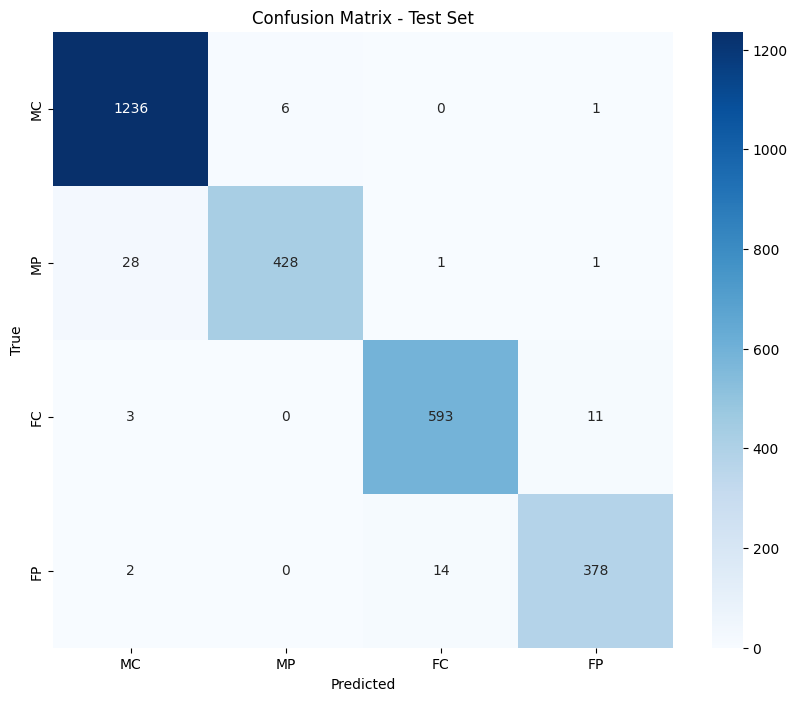

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model_on_test_set(model, test_loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            predictions = torch.argmax(outputs, axis=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    mcc = matthews_corrcoef(y_true, y_pred)

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix - Test Set")
    plt.show()

    return precision, recall, f1, mcc

final_model.load_state_dict(torch.load('/content/MA/final_group_classifier.pth'))
final_model.to(device)

precision, recall, f1, mcc = evaluate_model_on_test_set(final_model, test_loader)


In [ ]:
### classifier MP training

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet50_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

base_path = '/content/MA'
output_dir = base_path

# Class Mapping
classes = {
    "ALS": 0,
    "Covid-19": 1,
    "Dysphonie": 2,
    "Laryngitis": 3,
    "Parkinson": 4,
    "Rekurrensparese": 5
}

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32)
        if mel.ndim == 2:
            mel = mel.unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

# Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes=7):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

train_set_path = os.path.join(base_path, "train_set.xlsx")
test_set_path = os.path.join(base_path, "test_set.xlsx")
train_df = pd.read_excel(train_set_path)
test_df = pd.read_excel(test_set_path)

def filter_mp_group(df):
    filtered_df = df[(df['Group'] == 'MP') & (df['Pathology'] != 'HC')]
    if filtered_df.empty:
        raise ValueError("No valid samples found after filtering for Group=MP and excluding HC.")
    return filtered_df

filtered_train_df = filter_mp_group(train_df)
filtered_test_df = filter_mp_group(test_df)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        pathology = row['Pathology']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and pathology in classes:
            files.append(full_path)
            labels.append(classes[pathology])
        else:
            print(f"Warning: File {full_path} does not exist or invalid pathology.")
    return files, labels

train_files, train_labels = get_file_paths_and_labels(filtered_train_df, base_path)
test_files, test_labels = get_file_paths_and_labels(filtered_test_df, base_path)

print(f"Filtered training samples: {len(train_files)}")
print(f"Filtered testing samples: {len(test_files)}")

test_dataset = MelDataset(test_files, test_labels)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

def plot_loss(train_losses, val_losses, fold):
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Train vs Validation Loss - Fold {fold}")
    plt.legend()
    plt.savefig(os.path.join(output_dir, f"loss_curve_fold_{fold}.png"))
    plt.close()

def save_metrics(metrics, fold):
    metrics_df = pd.DataFrame(metrics, columns=["Epoch", "MCC"])
    metrics_df.to_csv(os.path.join(output_dir, f"validation_metrics_fold_{fold}.csv"), index=False)

def save_test_metrics(fold, mcc):
    test_results_path = os.path.join(output_dir, "test_metrics_MP.csv")
    if not os.path.exists(test_results_path):
        with open(test_results_path, "w") as f:
            f.write("Fold,MCC\n")
    with open(test_results_path, "a") as f:
        f.write(f"{fold},{mcc:.4f}\n")

def evaluate_on_test_set(model, test_loader, fold):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Test Set (Fold {fold})")
    plt.savefig(os.path.join(output_dir, f"test_confusion_MP_matrix_fold_{fold}.png"))
    plt.close()

    mcc = matthews_corrcoef(y_true, y_pred)
    print(f"Test Set Results - Fold {fold}: MCC: {mcc:.4f}")
    save_test_metrics(fold, mcc)

batch_sizes = [32, 64]
learning_rates = [1e-3, 1e-4, 1e-5]
param_combinations = list(itertools.product(batch_sizes, learning_rates))
print("Hyperparameter combinations:")
for combo in param_combinations:
    print(combo)

best_params = None
best_model = None
best_val_mcc = -1

cv_results = []

for batch_size, lr in param_combinations:
    print(f"Testing parameter combination: batch_size={batch_size}, lr={lr}")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
    fold = 1
    fold_metrics = []

    for train_idx, val_idx in skf.split(train_files, train_labels):
        print(f"Starting Fold {fold} with batch_size={batch_size}, lr={lr}")

        train_dataset = MelDataset([train_files[i] for i in train_idx], [train_labels[i] for i in train_idx])
        val_dataset = MelDataset([train_files[i] for i in val_idx], [train_labels[i] for i in val_idx])
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        model = ResNet50Classifier(num_classes=len(classes)).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        train_losses, val_losses = [], []

        for epoch in range(20):
            model.train()
            total_train_loss = 0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                total_train_loss += loss.item()

            model.eval()
            total_val_loss = 0
            y_true, y_pred = [], []
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    total_val_loss += loss.item()
                    y_true.extend(labels.cpu().numpy())
                    y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

            train_loss = total_train_loss / len(train_loader)
            val_loss = total_val_loss / len(val_loader)
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

        mcc = matthews_corrcoef(y_true, y_pred)
        fold_metrics.append(mcc)
        print(f"Fold {fold} | MCC: {mcc:.4f}")
        fold += 1

    avg_mcc = sum(fold_metrics) / len(fold_metrics)
    cv_results.append((batch_size, lr, avg_mcc))

    if avg_mcc > best_val_mcc:
        best_val_mcc = avg_mcc
        best_params = (batch_size, lr)
        best_model = model

print(f"Best parameters: batch_size={best_params[0]}, lr={best_params[1]} with MCC={best_val_mcc:.4f}")

# Retrain on whole training set
print("Retraining model with best parameters on full training set...")
final_train_dataset = MelDataset(train_files, train_labels)
final_train_loader = DataLoader(final_train_dataset, batch_size=best_params[0], shuffle=True)
final_model = ResNet50Classifier(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params[1])

for epoch in range(20):
    final_model.train()
    total_train_loss = 0
    for inputs, labels in final_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = final_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(final_train_loader)
    print(f"Retrain Epoch {epoch + 1}: Train Loss: {avg_train_loss:.4f}")

model_save_path = os.path.join(output_dir, "best_resnet50_MP_model.pth")
torch.save(final_model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

print("Evaluating final model on test set...")
evaluate_on_test_set(final_model, test_loader, "Final")


Using device: cuda
Filtered training samples: 5599
Filtered testing samples: 458
Hyperparameter combinations:
(32, 0.001)
(32, 0.0001)
(32, 1e-05)
(64, 0.001)
(64, 0.0001)
(64, 1e-05)
Testing parameter combination: batch_size=32, lr=0.001
Starting Fold 1 with batch_size=32, lr=0.001


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 161MB/s]


Epoch 1: Train Loss: 0.5925, Validation Loss: 1.1733
Epoch 2: Train Loss: 0.1877, Validation Loss: 0.2715
Epoch 3: Train Loss: 0.1305, Validation Loss: 0.0956
Epoch 4: Train Loss: 0.1045, Validation Loss: 0.3856
Epoch 5: Train Loss: 0.0639, Validation Loss: 0.0945
Epoch 6: Train Loss: 0.0448, Validation Loss: 0.0058
Epoch 7: Train Loss: 0.0103, Validation Loss: 0.0892
Epoch 8: Train Loss: 0.0395, Validation Loss: 0.0848
Epoch 9: Train Loss: 0.0827, Validation Loss: 0.0089
Epoch 10: Train Loss: 0.0244, Validation Loss: 0.1348
Epoch 11: Train Loss: 0.0470, Validation Loss: 0.0177
Epoch 12: Train Loss: 0.0188, Validation Loss: 0.0365
Epoch 13: Train Loss: 0.0127, Validation Loss: 0.0081
Epoch 14: Train Loss: 0.0068, Validation Loss: 0.0067
Epoch 15: Train Loss: 0.0013, Validation Loss: 0.0004
Epoch 16: Train Loss: 0.0004, Validation Loss: 0.0000
Epoch 17: Train Loss: 0.0408, Validation Loss: 0.2514
Epoch 18: Train Loss: 0.0753, Validation Loss: 0.0082
Epoch 19: Train Loss: 0.0474, Validat

In [ ]:
### classifier MP test

<ipython-input-4-5a625e53b0fb>:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_model.load_state_dict(torch.load('/content/MA/best_resnet50_MP_model.pth'))


Precision: 0.9890
Recall: 0.9891
F1 Score: 0.9890
MCC: 0.9828


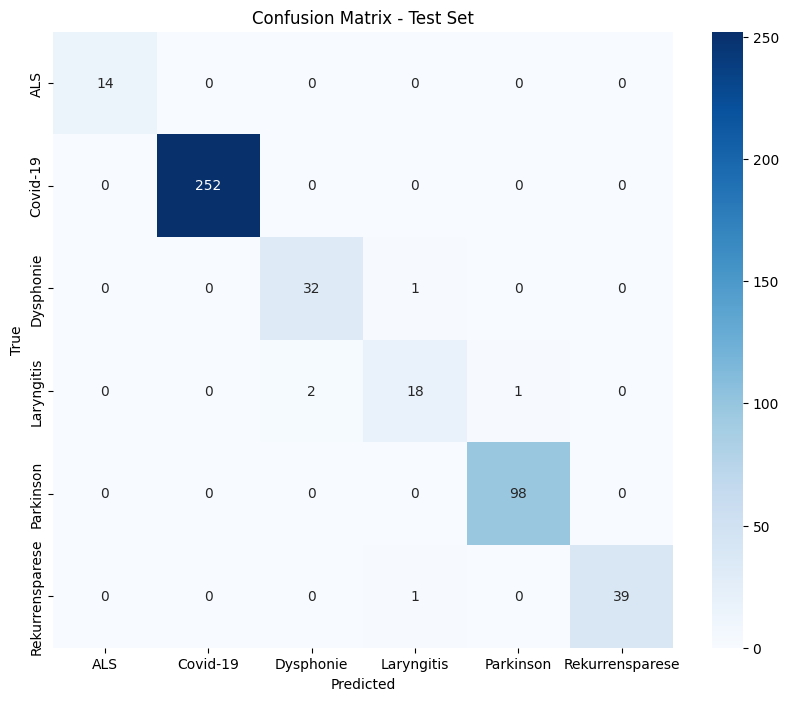

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model_on_test_set(model, test_loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            predictions = torch.argmax(outputs, axis=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    mcc = matthews_corrcoef(y_true, y_pred)

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix - Test Set")
    plt.show()

    return precision, recall, f1, mcc

final_model.load_state_dict(torch.load('/content/MA/best_resnet50_MP_model.pth'))
final_model.to(device)

precision, recall, f1, mcc = evaluate_model_on_test_set(final_model, test_loader)

In [ ]:
## classifier FP training

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet50_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import itertools


random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

base_path = '/content/MA'
output_dir = base_path

# Class Mapping
classes = {
    "ALS": 0,
    "Covid-19": 1,
    "Dysphonie": 2,
    "Laryngitis": 3,
    "Parkinson": 4,
    "Rekurrensparese": 5
}

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32)
        if mel.ndim == 2:
            mel = mel.unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

# Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes=7):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

train_set_path = os.path.join(base_path, "train_set.xlsx")
test_set_path = os.path.join(base_path, "test_set.xlsx")
train_df = pd.read_excel(train_set_path)
test_df = pd.read_excel(test_set_path)

def filter_mp_group(df):
    filtered_df = df[(df['Group'] == 'FP') & (df['Pathology'] != 'HC')]
    if filtered_df.empty:
        raise ValueError("No valid samples found after filtering for Group=FP and excluding HC.")
    return filtered_df

filtered_train_df = filter_mp_group(train_df)
filtered_test_df = filter_mp_group(test_df)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        pathology = row['Pathology']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and pathology in classes:
            files.append(full_path)
            labels.append(classes[pathology])
        else:
            print(f"Warning: File {full_path} does not exist or invalid pathology.")
    return files, labels

train_files, train_labels = get_file_paths_and_labels(filtered_train_df, base_path)
test_files, test_labels = get_file_paths_and_labels(filtered_test_df, base_path)

print(f"Filtered training samples: {len(train_files)}")
print(f"Filtered testing samples: {len(test_files)}")

test_dataset = MelDataset(test_files, test_labels)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

def plot_loss(train_losses, val_losses, fold):
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Train vs Validation Loss - Fold {fold}")
    plt.legend()
    plt.savefig(os.path.join(output_dir, f"loss_curve_fold_{fold}.png"))
    plt.close()

def save_metrics(metrics, fold):
    metrics_df = pd.DataFrame(metrics, columns=["Epoch", "MCC"])
    metrics_df.to_csv(os.path.join(output_dir, f"validation_metrics_fold_{fold}.csv"), index=False)

def save_test_metrics(fold, mcc):
    test_results_path = os.path.join(output_dir, "test_metrics_FP.csv")
    if not os.path.exists(test_results_path):
        with open(test_results_path, "w") as f:
            f.write("Fold,MCC\n")
    with open(test_results_path, "a") as f:
        f.write(f"{fold},{mcc:.4f}\n")

def evaluate_on_test_set(model, test_loader, fold):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - Test Set (Fold {fold})")
    plt.savefig(os.path.join(output_dir, f"test_confusion_FP_matrix_fold_{fold}.png"))
    plt.close()

    mcc = matthews_corrcoef(y_true, y_pred)
    print(f"Test Set Results - Fold {fold}: MCC: {mcc:.4f}")
    save_test_metrics(fold, mcc)

batch_sizes = [32, 64]
learning_rates = [1e-3, 1e-4, 1e-5]
param_combinations = list(itertools.product(batch_sizes, learning_rates))
print("Hyperparameter combinations:")
for combo in param_combinations:
    print(combo)

best_params = None
best_model = None
best_val_mcc = -1

cv_results = []

for batch_size, lr in param_combinations:
    print(f"Testing parameter combination: batch_size={batch_size}, lr={lr}")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
    fold = 1
    fold_metrics = []

    for train_idx, val_idx in skf.split(train_files, train_labels):
        print(f"Starting Fold {fold} with batch_size={batch_size}, lr={lr}")

        train_dataset = MelDataset([train_files[i] for i in train_idx], [train_labels[i] for i in train_idx])
        val_dataset = MelDataset([train_files[i] for i in val_idx], [train_labels[i] for i in val_idx])
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        model = ResNet50Classifier(num_classes=len(classes)).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        train_losses, val_losses = [], []

        for epoch in range(20):
            model.train()
            total_train_loss = 0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                total_train_loss += loss.item()

            model.eval()
            total_val_loss = 0
            y_true, y_pred = [], []
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    total_val_loss += loss.item()
                    y_true.extend(labels.cpu().numpy())
                    y_pred.extend(torch.argmax(outputs, axis=1).cpu().numpy())

            train_loss = total_train_loss / len(train_loader)
            val_loss = total_val_loss / len(val_loader)
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

        mcc = matthews_corrcoef(y_true, y_pred)
        fold_metrics.append(mcc)
        print(f"Fold {fold} | MCC: {mcc:.4f}")
        fold += 1

    avg_mcc = sum(fold_metrics) / len(fold_metrics)
    cv_results.append((batch_size, lr, avg_mcc))

    if avg_mcc > best_val_mcc:
        best_val_mcc = avg_mcc
        best_params = (batch_size, lr)
        best_model = model

print(f"Best parameters: batch_size={best_params[0]}, lr={best_params[1]} with MCC={best_val_mcc:.4f}")

# Retrain on whole training set
print("Retraining model with best parameters on full training set...")
final_train_dataset = MelDataset(train_files, train_labels)
final_train_loader = DataLoader(final_train_dataset, batch_size=best_params[0], shuffle=True)
final_model = ResNet50Classifier(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params[1])

for epoch in range(20):
    final_model.train()
    total_train_loss = 0
    for inputs, labels in final_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = final_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(final_train_loader)
    print(f"Retrain Epoch {epoch + 1}: Train Loss: {avg_train_loss:.4f}")

model_save_path = os.path.join(output_dir, "best_resnet50_FP_model.pth")
torch.save(final_model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

print("Evaluating final model on test set...")
evaluate_on_test_set(final_model, test_loader, "Final")


Using device: cuda
Filtered training samples: 3427
Filtered testing samples: 394
Hyperparameter combinations:
(32, 0.001)
(32, 0.0001)
(32, 1e-05)
(64, 0.001)
(64, 0.0001)
(64, 1e-05)
Testing parameter combination: batch_size=32, lr=0.001
Starting Fold 1 with batch_size=32, lr=0.001


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 206MB/s]


Epoch 1: Train Loss: 0.6491, Validation Loss: 0.4143
Epoch 2: Train Loss: 0.3344, Validation Loss: 0.4733
Epoch 3: Train Loss: 0.2987, Validation Loss: 0.1837
Epoch 4: Train Loss: 0.1899, Validation Loss: 0.1076
Epoch 5: Train Loss: 0.1305, Validation Loss: 3.0425
Epoch 6: Train Loss: 0.1825, Validation Loss: 2.1072
Epoch 7: Train Loss: 0.1097, Validation Loss: 0.2812
Epoch 8: Train Loss: 0.0922, Validation Loss: 0.1498
Epoch 9: Train Loss: 0.0991, Validation Loss: 0.0673
Epoch 10: Train Loss: 0.1378, Validation Loss: 0.1471
Epoch 11: Train Loss: 0.0420, Validation Loss: 0.0514
Epoch 12: Train Loss: 0.0176, Validation Loss: 0.0252
Epoch 13: Train Loss: 0.0389, Validation Loss: 0.0579
Epoch 14: Train Loss: 0.0143, Validation Loss: 0.0221
Epoch 15: Train Loss: 0.0498, Validation Loss: 0.0493
Epoch 16: Train Loss: 0.0273, Validation Loss: 0.0274
Epoch 17: Train Loss: 0.0196, Validation Loss: 0.0327
Epoch 18: Train Loss: 0.0173, Validation Loss: 0.1119
Epoch 19: Train Loss: 0.0326, Validat

In [ ]:
### classifier FP test

<ipython-input-4-193dd2f226d0>:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  final_model.load_state_dict(torch.load('/content/MA/best_resnet50_FP_model.pth'))


Precision: 0.9644
Recall: 0.9645
F1 Score: 0.9642
MCC: 0.9527


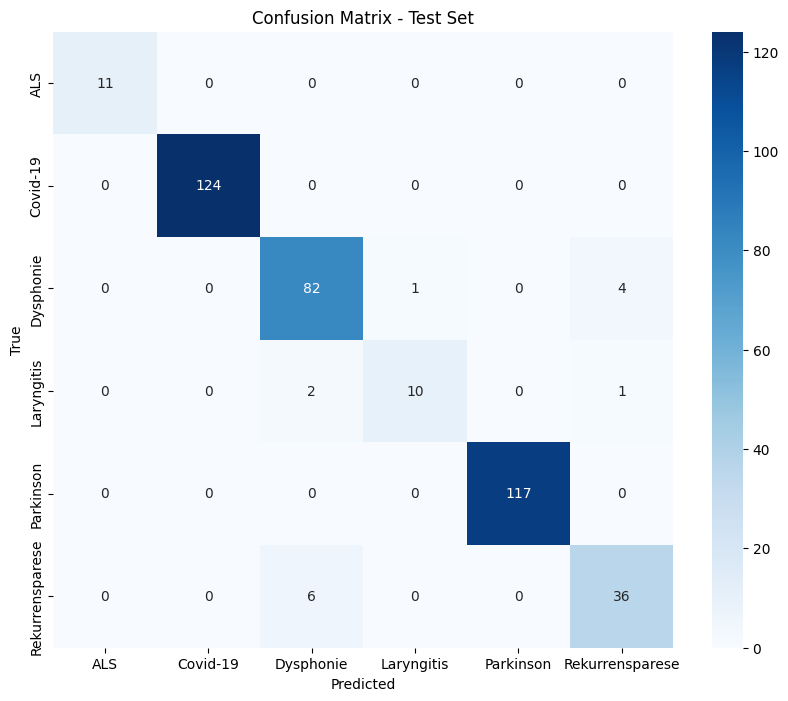

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model_on_test_set(model, test_loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            predictions = torch.argmax(outputs, axis=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    mcc = matthews_corrcoef(y_true, y_pred)

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes.keys(), yticklabels=classes.keys())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix - Test Set")
    plt.show()

    return precision, recall, f1, mcc

final_model.load_state_dict(torch.load('/content/MA/best_resnet50_FP_model.pth'))
final_model.to(device)

precision, recall, f1, mcc = evaluate_model_on_test_set(final_model, test_loader)

In [ ]:
### two stage architecture test

Using device: cuda


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 214MB/s]
<ipython-input-2-c5a47238f324>:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded

Total samples: 2702
Samples classified as HC: 1878
Precision: 0.9734
Recall: 0.9734
F1 Score: 0.9731
MCC: 0.9466


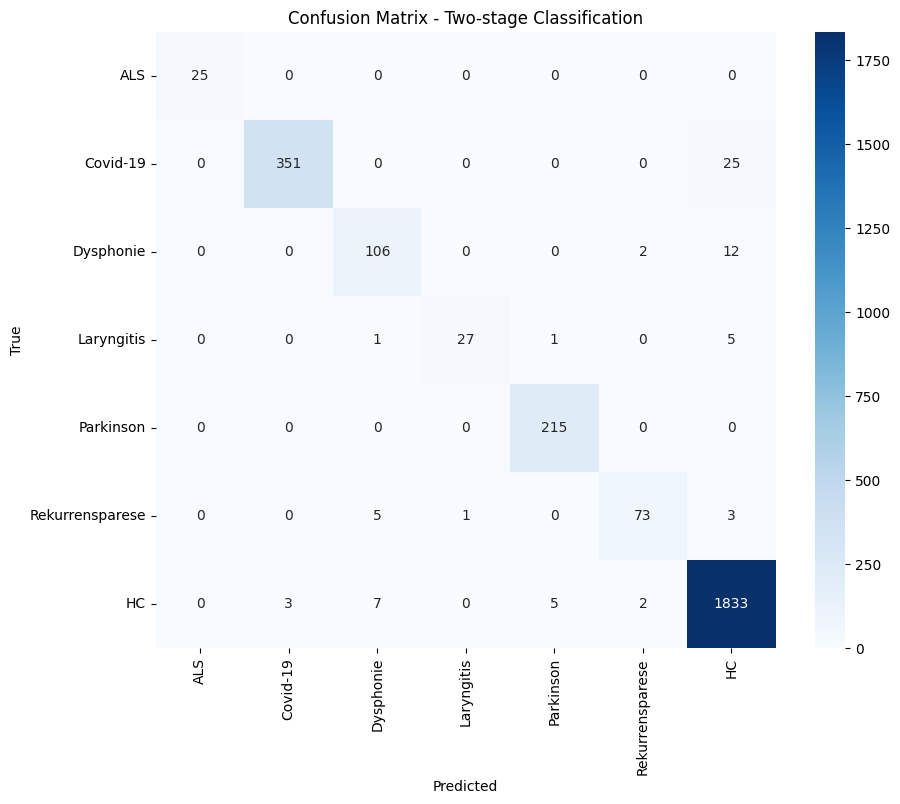

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import random
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import matthews_corrcoef, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import models
from torchvision.models import ResNet50_Weights

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Class Mapping
group_classes = {"MC": 0, "MP": 1, "FC": 2, "FP": 3}
disease_classes = {
    "ALS": 0,
    "Covid-19": 1,
    "Dysphonie": 2,
    "Laryngitis": 3,
    "Parkinson": 4,
    "Rekurrensparese": 5,
    "HC": 6
}

# Class ResNet-50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes):
        super(ResNet50Classifier, self).__init__()
        self.base_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

class MelDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = np.load(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

def load_model(model_path, num_classes):
    model = ResNet50Classifier(num_classes=num_classes).to(device)
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    return model

def get_test_loader(test_files, test_labels, batch_size=32):
    test_dataset = MelDataset(test_files, test_labels)
    return DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Load Group Classifier
group_model = load_model("/content/MA/final_group_classifier.pth", num_classes=4)

# Load MP and FP Classifier
mp_model = load_model("/content/MA/best_resnet50_MP_model.pth", num_classes=6)
fp_model = load_model("/content/MA/best_resnet50_FP_model.pth", num_classes=6)

def get_file_paths_and_labels(df, base_dir):
    files, labels = [], []
    for _, row in df.iterrows():
        relative_path = row['Full_Path']
        pathology = row['Pathology']
        full_path = os.path.join(base_dir, relative_path.replace('\\', '/'))
        if os.path.exists(full_path) and pathology in disease_classes:
            files.append(full_path)
            labels.append(disease_classes[pathology])
        else:
            print(f"Warning: File {full_path} does not exist or invalid pathology.")
    return files, labels

test_set_path = os.path.join("/content/MA", "test_set.xlsx")
test_df = pd.read_excel(test_set_path)
test_files, test_labels = get_file_paths_and_labels(test_df, "/content/MA")

test_loader = get_test_loader(test_files, test_labels)

y_true, y_pred = [], []

total_samples, mc_fc_count = 0, 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.numpy()
        if len(inputs.shape) == 5:
            inputs = inputs.squeeze(2)
        group_outputs = group_model(inputs)
        group_preds = torch.argmax(group_outputs, axis=1).cpu().numpy()

        for i, group_pred in enumerate(group_preds):
            if group_pred in [group_classes["MC"], group_classes["FC"]]:
                y_true.append(labels[i])
                y_pred.append(disease_classes["HC"])
                mc_fc_count += 1
            elif group_pred == group_classes["MP"]:
                mp_output = mp_model(inputs[i].unsqueeze(0))
                mp_pred = torch.argmax(mp_output, axis=1).cpu().item()
                y_true.append(labels[i])
                y_pred.append(mp_pred)
            elif group_pred == group_classes["FP"]:
                fp_output = fp_model(inputs[i].unsqueeze(0))
                fp_pred = torch.argmax(fp_output, axis=1).cpu().item()
                y_true.append(labels[i])
                y_pred.append(fp_pred)

print(f"Total samples: {len(test_labels)}")
print(f"Samples classified as HC: {mc_fc_count}")

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
mcc = matthews_corrcoef(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=disease_classes.keys(),
            yticklabels=disease_classes.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Two-stage Classification")
plt.show()
